# ============================================================
# Weekly + Daily + 4H + 1H Multi-Timeframe DQN + SMC Trading System
# Google Colab Complete Version
# ============================================================
# 功能：
# 1. 使用 1H 作為主交易時區，每根 1H K 線做一次決策
# 2. 使用 1H resample 成 4H
# 3. 使用 Daily 作為高時區 SMC 分析
# 4. 使用 Daily resample 成 Weekly，作為最高時區市場結構背景
# 5. 建立 W1 / D1 / H4 / H1 的技術指標與 SMC 特徵
# 6. 使用 merge_asof 將 W1 / D1 / H4 對齊到 H1
# 7. 使用 DQN 學習在多時區 SMC 狀態下的最佳目標部位
# 8. 輸出回測績效、Q Values、最新策略建議與 CSV 報告
#
# 重要說明：
# - 此程式僅供研究與模型驗證，不構成投資建議。
# - Yahoo Finance 對 intraday 1H 資料有期間限制，台股 2330.TW 可能無法抓長期 1H。
# - 若 2330.TW 仍抓不到 1H，請先用 AAPL / MSFT / TSLA 測試完整流程。
# - SMC 特徵為規則化近似，不等於完整人工 SMC 判讀。
# - 目前是現貨多方模型，不支援放空。
# - 實戰前需加入滑價、實際下單單位、停損停利、Walk-forward validation。

# ============================================================
# Cell 1：安裝套件
# ============================================================

In [1]:
!pip -q install yfinance ta

  Preparing metadata (setup.py) ... done


# ============================================================
# Cell 2：匯入套件與全域設定
# ============================================================

In [2]:
import random
from dataclasses import dataclass
from collections import deque
from typing import List, Tuple, Dict, Optional

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from ta.momentum import RSIIndicator
from ta.volatility import AverageTrueRange
from ta.trend import MACD

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)

DEVICE: cuda


# ============================================================
# Cell 3：參數設定
# ============================================================

In [3]:
@dataclass
class Config:
    # 建議：
    # - 台股：2330.TW 可測，但 1H intraday 資料可能有限。
    # - 若資料抓不到，請先改成 AAPL / MSFT / TSLA 驗證流程。
    ticker: str = "2330.TW"

    # 1H 資料若抓不到長區間，程式會自動 fallback 到較短 period。
    start_date: str = "2024-04-29"
    end_date: str = "2026-04-29"

    # 主交易時區
    base_interval: str = "1h"

    # yfinance intraday fallback periods，從長到短嘗試
    intraday_fallback_periods: Tuple[str, ...] = ("730d", "365d", "180d", "90d", "60d")

    # 為了讓 W1 / D1 指標有足夠 rolling window，Daily 往前多抓的天數
    daily_extra_days: int = 800

    # 資料切分
    train_ratio: float = 0.70
    val_ratio: float = 0.15
    test_ratio: float = 0.15

    # 交易環境
    initial_cash: float = 100000.0
    transaction_cost_rate: float = 0.001425
    tax_rate: float = 0.003

    # DQN 訓練
    episodes: int = 25
    batch_size: int = 64
    gamma: float = 0.95
    lr: float = 1e-4
    replay_size: int = 100000
    min_replay_size: int = 1200
    target_update_freq: int = 300

    # Epsilon-greedy
    epsilon_start: float = 1.0
    epsilon_min: float = 0.03
    epsilon_decay: float = 0.965

    # Reward 權重
    reward_scale: float = 100.0
    drawdown_penalty: float = 0.10
    trade_penalty: float = 0.003
    mtf_bonus_weight: float = 0.003
    higher_tf_conflict_penalty: float = 0.002

    # SMC 特徵參數
    swing_window: int = 5
    lookback_range: int = 60

    # Risk Reward Ratio 計算參數
    rr_atr_multiplier: float = 1.5
    rr_target: float = 2.0
    rr_swing_buffer_pct: float = 0.002
    min_rr_threshold: float = 1.5

cfg = Config()

# 現貨多方模型：目標部位比例
ACTION_POSITION_RATIOS = [0.0, 0.25, 0.50, 1.0]
ACTION_NAMES = {
    0: "Stay in Cash / 0% Position",
    1: "Adjust to 25% Position",
    2: "Adjust to 50% Position",
    3: "Adjust to 100% Position",
}

# ============================================================
# Cell 4：Datetime 與 OHLCV 工具函式
# ============================================================

In [4]:
def ensure_datetime_index(df: pd.DataFrame) -> pd.DataFrame:
    """確保 DataFrame 使用乾淨的 DatetimeIndex。"""
    df = df.copy()

    if df.empty:
        return df

    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)

    # 移除 timezone，避免 merge_asof 時 timezone 不一致
    if df.index.tz is not None:
        df.index = df.index.tz_convert(None)

    df = df.sort_index()
    df.index.name = None
    return df


def reset_datetime_index(df: pd.DataFrame) -> pd.DataFrame:
    """
    穩定產生 datetime 欄位。
    不依賴 index.name，因此可避免 datetime index name 不一致的 KeyError。
    """
    df = ensure_datetime_index(df)
    out = df.copy()
    out["datetime"] = out.index
    out = out.reset_index(drop=True)
    out = out.sort_values("datetime")
    return out


def normalize_ohlcv_columns(df: pd.DataFrame) -> pd.DataFrame:
    """將 yfinance 下載資料整理成 open/high/low/close/volume。"""
    if df.empty:
        return df

    df = df.copy()

    if isinstance(df.columns, pd.MultiIndex):
        level0 = list(df.columns.get_level_values(0))
        if "Open" in level0 or "Close" in level0:
            df.columns = df.columns.get_level_values(0)
        else:
            df.columns = df.columns.get_level_values(-1)

    df = df.rename(columns={
        "Open": "open",
        "High": "high",
        "Low": "low",
        "Close": "close",
        "Adj Close": "adj_close",
        "Volume": "volume",
    })

    required_cols = ["open", "high", "low", "close", "volume"]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing OHLCV columns: {missing}. Available columns: {list(df.columns)}")

    df = df[required_cols].copy()
    df = df.dropna()
    df = ensure_datetime_index(df)
    return df


def download_ohlcv_basic(
    ticker: str,
    start: Optional[str] = None,
    end: Optional[str] = None,
    interval: str = "1d",
    period: Optional[str] = None,
) -> pd.DataFrame:
    """yfinance 基礎下載函式。"""
    kwargs = {
        "tickers": ticker,
        "interval": interval,
        "auto_adjust": True,
        "progress": False,
        "threads": True,
    }

    if period is not None:
        kwargs["period"] = period
    else:
        kwargs["start"] = start
        kwargs["end"] = end

    df = yf.download(**kwargs)
    df = normalize_ohlcv_columns(df)
    return df


def download_ohlcv_with_fallback(
    ticker: str,
    start: str,
    end: str,
    interval: str,
    fallback_periods: Tuple[str, ...] = ("730d", "365d", "180d", "90d", "60d"),
) -> pd.DataFrame:
    """
    下載 OHLCV。
    若 intraday 1H 使用 start/end 抓不到，會自動改用 period fallback。
    """
    print(f"Downloading {ticker}, interval={interval}, start={start}, end={end} ...")

    try:
        df = download_ohlcv_basic(ticker=ticker, start=start, end=end, interval=interval)
        if not df.empty:
            print(f"Downloaded by start/end: rows={len(df)}, {df.index.min()} -> {df.index.max()}")
            return df
    except Exception as e:
        print(f"Start/end download failed: {e}")

    # intraday fallback
    if interval.lower() in {"1h", "60m", "30m", "15m", "5m", "1m"}:
        alt_intervals = [interval]
        if interval.lower() == "1h":
            alt_intervals.append("60m")
        elif interval.lower() == "60m":
            alt_intervals.append("1h")

        for alt_interval in alt_intervals:
            for period in fallback_periods:
                try:
                    print(f"Trying fallback: interval={alt_interval}, period={period} ...")
                    df = download_ohlcv_basic(
                        ticker=ticker,
                        interval=alt_interval,
                        period=period,
                    )
                    if not df.empty:
                        print(f"Downloaded by period fallback: rows={len(df)}, {df.index.min()} -> {df.index.max()}")
                        return df
                except Exception as e:
                    print(f"Fallback failed: interval={alt_interval}, period={period}, error={e}")

    # daily / weekly fallback
    if interval.lower() in {"1d", "1wk"}:
        for period in fallback_periods:
            try:
                print(f"Trying daily/weekly fallback: interval={interval}, period={period} ...")
                df = download_ohlcv_basic(
                    ticker=ticker,
                    interval=interval,
                    period=period,
                )
                if not df.empty:
                    print(f"Downloaded by daily/weekly fallback: rows={len(df)}, {df.index.min()} -> {df.index.max()}")
                    return df
            except Exception as e:
                print(f"Daily/weekly fallback failed: interval={interval}, period={period}, error={e}")

    raise ValueError(
        f"No data downloaded for {ticker}, interval={interval}. "
        "For Taiwan stocks, Yahoo Finance may not provide stable long intraday data. "
        "Try a shorter start_date, use AAPL/MSFT for testing, or use a paid/local data source."
    )


def resample_ohlcv(df: pd.DataFrame, rule: str) -> pd.DataFrame:
    """用較低時區 OHLCV resample 成較高時區。"""
    df = ensure_datetime_index(df)

    out = pd.DataFrame({
        "open": df["open"].resample(rule).first(),
        "high": df["high"].resample(rule).max(),
        "low": df["low"].resample(rule).min(),
        "close": df["close"].resample(rule).last(),
        "volume": df["volume"].resample(rule).sum(),
    })

    out = out.dropna()
    out = ensure_datetime_index(out)
    return out

# ============================================================
# Cell 5：下載 1H / 4H / D1 / W1 資料
# ============================================================

In [5]:
# 1H 主交易資料：使用 fallback 下載
df_h1_raw = download_ohlcv_with_fallback(
    ticker=cfg.ticker,
    start=cfg.start_date,
    end=cfg.end_date,
    interval=cfg.base_interval,
    fallback_periods=cfg.intraday_fallback_periods,
)

# 4H：由 1H resample 而來
df_h4_raw = resample_ohlcv(df_h1_raw, "4h")

# D1：高時區背景。
# 往前多抓 daily_extra_days，讓 W1 / D1 的 rolling 指標有足夠資料。
daily_start = str((df_h1_raw.index.min() - pd.Timedelta(days=cfg.daily_extra_days)).date())
daily_end = str((df_h1_raw.index.max() + pd.Timedelta(days=2)).date())

df_d1_raw = download_ohlcv_with_fallback(
    ticker=cfg.ticker,
    start=daily_start,
    end=daily_end,
    interval="1d",
    fallback_periods=("10y", "5y", "2y", "1y"),
)

# W1：由 D1 resample 而來，作為最高時區市場結構背景
df_w1_raw = resample_ohlcv(df_d1_raw, "1W")

print("========== Raw Data Summary ==========")
print("H1 rows:", len(df_h1_raw), df_h1_raw.index.min(), "->", df_h1_raw.index.max())
print("H4 rows:", len(df_h4_raw), df_h4_raw.index.min(), "->", df_h4_raw.index.max())
print("D1 rows:", len(df_d1_raw), df_d1_raw.index.min(), "->", df_d1_raw.index.max())
print("W1 rows:", len(df_w1_raw), df_w1_raw.index.min(), "->", df_w1_raw.index.max())

ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['2330.TW']: YFPricesMissingError('possibly delisted; no price data found  (1h 2024-04-29 -> 2026-04-29) (Yahoo error = "1h data not available for startTime=1714320000 and endTime=1777392000. The requested range must be within the last 730 days.")')


Trying fallback: interval=1h, period=730d ...
Downloaded by period fallback: rows=3644, 2023-05-10 01:00:00 -> 2026-05-13 05:00:00
Downloaded by start/end: rows=1262, 2021-03-02 00:00:00 -> 2026-05-13 00:00:00
========== Raw Data Summary ==========
H1 rows: 3644 2023-05-10 01:00:00 -> 2026-05-13 05:00:00
H4 rows: 1458 2023-05-10 00:00:00 -> 2026-05-13 04:00:00
D1 rows: 1262 2021-03-02 00:00:00 -> 2026-05-13 00:00:00
W1 rows: 268 2021-03-07 00:00:00 -> 2026-05-17 00:00:00


# ============================================================
# Cell 6：基礎指標與 SMC 特徵工程
# ============================================================

In [6]:
def add_basic_indicators(df: pd.DataFrame, prefix: str) -> pd.DataFrame:
    """加入基礎技術指標，欄位名稱加上 prefix。"""
    df = ensure_datetime_index(df)
    df = df.copy()

    # 保留各時區自己的價格欄位，後續用於 W1 / D1 / H4 / H1 各週期 RR 計算
    df[f"{prefix}_open"] = df["open"]
    df[f"{prefix}_high"] = df["high"]
    df[f"{prefix}_low"] = df["low"]
    df[f"{prefix}_close"] = df["close"]

    df[f"{prefix}_return_1"] = df["close"].pct_change()
    df[f"{prefix}_return_5"] = df["close"].pct_change(5)
    df[f"{prefix}_volume_change"] = df["volume"].pct_change().replace([np.inf, -np.inf], np.nan)

    df[f"{prefix}_sma_10"] = df["close"].rolling(10).mean()
    df[f"{prefix}_sma_20"] = df["close"].rolling(20).mean()
    df[f"{prefix}_sma_60"] = df["close"].rolling(60).mean()

    df[f"{prefix}_ma_gap_10"] = df["close"] / df[f"{prefix}_sma_10"] - 1
    df[f"{prefix}_ma_gap_20"] = df["close"] / df[f"{prefix}_sma_20"] - 1
    df[f"{prefix}_ma_gap_60"] = df["close"] / df[f"{prefix}_sma_60"] - 1

    df[f"{prefix}_rsi"] = RSIIndicator(close=df["close"], window=14).rsi()

    atr = AverageTrueRange(
        high=df["high"],
        low=df["low"],
        close=df["close"],
        window=14,
    )
    df[f"{prefix}_atr"] = atr.average_true_range()
    df[f"{prefix}_atr_pct"] = df[f"{prefix}_atr"] / df["close"]

    macd = MACD(close=df["close"])
    df[f"{prefix}_macd"] = macd.macd()
    df[f"{prefix}_macd_signal"] = macd.macd_signal()
    df[f"{prefix}_macd_diff"] = macd.macd_diff()

    df = df.replace([np.inf, -np.inf], np.nan)
    return df


def add_smc_features(
    df: pd.DataFrame,
    prefix: str,
    swing_window: int = 5,
    lookback_range: int = 60,
) -> pd.DataFrame:
    """MVP 規則化 SMC 特徵，每個欄位會加上 prefix。"""
    df = ensure_datetime_index(df)
    df = df.copy()

    swing_high_col = f"{prefix}_swing_high"
    swing_low_col = f"{prefix}_swing_low"
    last_high_col = f"{prefix}_last_swing_high"
    last_low_col = f"{prefix}_last_swing_low"

    df[swing_high_col] = 0
    df[swing_low_col] = 0

    for i in range(swing_window, len(df) - swing_window):
        local_high = df["high"].iloc[i - swing_window:i + swing_window + 1].max()
        local_low = df["low"].iloc[i - swing_window:i + swing_window + 1].min()

        if df["high"].iloc[i] == local_high:
            df.iloc[i, df.columns.get_loc(swing_high_col)] = 1
        if df["low"].iloc[i] == local_low:
            df.iloc[i, df.columns.get_loc(swing_low_col)] = 1

    df[last_high_col] = np.nan
    df[last_low_col] = np.nan

    last_high = np.nan
    last_low = np.nan
    for i in range(len(df)):
        if df[swing_high_col].iloc[i] == 1:
            last_high = df["high"].iloc[i]
        if df[swing_low_col].iloc[i] == 1:
            last_low = df["low"].iloc[i]

        df.iloc[i, df.columns.get_loc(last_high_col)] = last_high
        df.iloc[i, df.columns.get_loc(last_low_col)] = last_low

    # BOS
    df[f"{prefix}_bos_bullish"] = (
        (df["close"] > df[last_high_col].shift(1))
        & df[last_high_col].shift(1).notna()
    ).astype(int)

    df[f"{prefix}_bos_bearish"] = (
        (df["close"] < df[last_low_col].shift(1))
        & df[last_low_col].shift(1).notna()
    ).astype(int)

    # Structure direction
    df[f"{prefix}_structure_direction"] = 0
    current_dir = 0
    for i in range(len(df)):
        if df[f"{prefix}_bos_bullish"].iloc[i] == 1:
            current_dir = 1
        elif df[f"{prefix}_bos_bearish"].iloc[i] == 1:
            current_dir = -1
        df.iloc[i, df.columns.get_loc(f"{prefix}_structure_direction")] = current_dir

    # CHOCH
    df[f"{prefix}_choch_bullish"] = (
        (df[f"{prefix}_structure_direction"].shift(1) == -1)
        & (df[f"{prefix}_bos_bullish"] == 1)
    ).astype(int)

    df[f"{prefix}_choch_bearish"] = (
        (df[f"{prefix}_structure_direction"].shift(1) == 1)
        & (df[f"{prefix}_bos_bearish"] == 1)
    ).astype(int)

    # Liquidity Sweep
    df[f"{prefix}_prev_high_20"] = df["high"].rolling(20).max().shift(1)
    df[f"{prefix}_prev_low_20"] = df["low"].rolling(20).min().shift(1)

    df[f"{prefix}_liquidity_sweep_high"] = (
        (df["high"] > df[f"{prefix}_prev_high_20"])
        & (df["close"] < df[f"{prefix}_prev_high_20"])
    ).astype(int)

    df[f"{prefix}_liquidity_sweep_low"] = (
        (df["low"] < df[f"{prefix}_prev_low_20"])
        & (df["close"] > df[f"{prefix}_prev_low_20"])
    ).astype(int)

    # Premium / Discount
    df[f"{prefix}_range_high"] = df["high"].rolling(lookback_range).max()
    df[f"{prefix}_range_low"] = df["low"].rolling(lookback_range).min()
    df[f"{prefix}_range_position"] = (
        (df["close"] - df[f"{prefix}_range_low"])
        / (df[f"{prefix}_range_high"] - df[f"{prefix}_range_low"])
    )
    df[f"{prefix}_premium_zone"] = (df[f"{prefix}_range_position"] > 0.5).astype(int)
    df[f"{prefix}_discount_zone"] = (df[f"{prefix}_range_position"] <= 0.5).astype(int)

    # FVG MVP
    df[f"{prefix}_bullish_fvg"] = (df["low"] > df["high"].shift(2)).astype(int)
    df[f"{prefix}_bearish_fvg"] = (df["high"] < df["low"].shift(2)).astype(int)

    # Order Block distance MVP
    df[f"{prefix}_bullish_ob_price"] = np.nan
    df[f"{prefix}_bearish_ob_price"] = np.nan

    last_bullish_ob = np.nan
    last_bearish_ob = np.nan

    for i in range(1, len(df)):
        if df["close"].iloc[i - 1] < df["open"].iloc[i - 1]:
            last_bullish_ob = df["low"].iloc[i - 1]
        if df["close"].iloc[i - 1] > df["open"].iloc[i - 1]:
            last_bearish_ob = df["high"].iloc[i - 1]

        df.iloc[i, df.columns.get_loc(f"{prefix}_bullish_ob_price")] = last_bullish_ob
        df.iloc[i, df.columns.get_loc(f"{prefix}_bearish_ob_price")] = last_bearish_ob

    df[f"{prefix}_bullish_ob_distance"] = (df["close"] - df[f"{prefix}_bullish_ob_price"]) / df["close"]
    df[f"{prefix}_bearish_ob_distance"] = (df[f"{prefix}_bearish_ob_price"] - df["close"]) / df["close"]

    # SMC score
    df[f"{prefix}_smc_bull_score"] = (
        df[f"{prefix}_bos_bullish"]
        + df[f"{prefix}_choch_bullish"]
        + df[f"{prefix}_liquidity_sweep_low"]
        + df[f"{prefix}_discount_zone"]
        + df[f"{prefix}_bullish_fvg"]
    )

    df[f"{prefix}_smc_bear_score"] = (
        df[f"{prefix}_bos_bearish"]
        + df[f"{prefix}_choch_bearish"]
        + df[f"{prefix}_liquidity_sweep_high"]
        + df[f"{prefix}_premium_zone"]
        + df[f"{prefix}_bearish_fvg"]
    )

    df[f"{prefix}_smc_bias"] = df[f"{prefix}_smc_bull_score"] - df[f"{prefix}_smc_bear_score"]

    df = df.replace([np.inf, -np.inf], np.nan)
    return df


def prepare_timeframe_features(df: pd.DataFrame, prefix: str, cfg: Config) -> pd.DataFrame:
    df = ensure_datetime_index(df)
    df = add_basic_indicators(df, prefix=prefix)
    df = add_smc_features(
        df,
        prefix=prefix,
        swing_window=cfg.swing_window,
        lookback_range=cfg.lookback_range,
    )
    return df


# 為四個時區建立特徵
df_h1_feat = prepare_timeframe_features(df_h1_raw, "h1", cfg)
df_h4_feat = prepare_timeframe_features(df_h4_raw, "h4", cfg)
df_d1_feat = prepare_timeframe_features(df_d1_raw, "d1", cfg)
df_w1_feat = prepare_timeframe_features(df_w1_raw, "w1", cfg)

print("========== Feature Data Summary ==========")
print("H1 feature rows:", len(df_h1_feat))
print("H4 feature rows:", len(df_h4_feat))
print("D1 feature rows:", len(df_d1_feat))
print("W1 feature rows:", len(df_w1_feat))

========== Feature Data Summary ==========
H1 feature rows: 3644
H4 feature rows: 1458
D1 feature rows: 1262
W1 feature rows: 268


# ============================================================
# Cell 7：多時區資料對齊
# ============================================================

In [7]:
def select_prefixed_feature_columns(df: pd.DataFrame, prefix: str) -> List[str]:
    """選出指定 prefix 的特徵欄位，排除原始 OHLCV。"""
    exclude = {"open", "high", "low", "close", "volume"}
    return [c for c in df.columns if c.startswith(f"{prefix}_") and c not in exclude]


def merge_asof_higher_tf(
    base_df: pd.DataFrame,
    higher_df: pd.DataFrame,
    higher_feature_cols: List[str],
) -> pd.DataFrame:
    """
    將高時區特徵對齊到主交易時區。
    direction='backward'：只使用當下以前已完成的高時區資訊，避免未來資料洩漏。
    """
    base = reset_datetime_index(base_df)

    higher = higher_df[higher_feature_cols].copy()
    higher = reset_datetime_index(higher)

    base = base.drop_duplicates(subset=["datetime"]).sort_values("datetime")
    higher = higher.drop_duplicates(subset=["datetime"]).sort_values("datetime")

    merged = pd.merge_asof(
        base,
        higher,
        on="datetime",
        direction="backward",
    )

    merged = merged.set_index("datetime")
    merged.index.name = None
    return merged


h4_feature_cols = select_prefixed_feature_columns(df_h4_feat, "h4")
d1_feature_cols = select_prefixed_feature_columns(df_d1_feat, "d1")
w1_feature_cols = select_prefixed_feature_columns(df_w1_feat, "w1")

# 以 H1 作為 base，依序合併 H4、D1、W1
mtf_df = merge_asof_higher_tf(df_h1_feat, df_h4_feat, h4_feature_cols)
mtf_df = merge_asof_higher_tf(mtf_df, df_d1_feat, d1_feature_cols)
mtf_df = merge_asof_higher_tf(mtf_df, df_w1_feat, w1_feature_cols)

mtf_df = mtf_df.replace([np.inf, -np.inf], np.nan).dropna()

print("MTF rows:", len(mtf_df))
print("MTF index:", type(mtf_df.index), mtf_df.index.name)
print(mtf_df.tail())

if len(mtf_df) < 500:
    print("WARNING: MTF rows are relatively small. Consider using AAPL/MSFT or a data provider with longer 1H history.")

MTF rows: 2880
MTF index: <class 'pandas.core.indexes.datetimes.DatetimeIndex'> None
                       open    high     low   close   volume  h1_open  \
2026-05-12 05:00:00  2260.0  2270.0  2255.0  2265.0  5564181   2260.0   
2026-05-13 01:00:00  2205.0  2230.0  2205.0  2220.0        0   2205.0   
2026-05-13 03:00:00  2205.0  2220.0  2205.0  2210.0  4974900   2205.0   
2026-05-13 04:00:00  2210.0  2220.0  2210.0  2215.0  3864392   2210.0   
2026-05-13 05:00:00  2220.0  2240.0  2215.0  2235.0  6717262   2220.0   

                     h1_high  h1_low  h1_close  h1_return_1  ...  \
2026-05-12 05:00:00   2270.0  2255.0    2265.0     0.000000  ...   
2026-05-13 01:00:00   2230.0  2205.0    2220.0    -0.019868  ...   
2026-05-13 03:00:00   2220.0  2205.0    2210.0     0.002268  ...   
2026-05-13 04:00:00   2220.0  2210.0    2215.0     0.002262  ...   
2026-05-13 05:00:00   2240.0  2215.0    2235.0     0.009029  ...   

                     w1_discount_zone  w1_bullish_fvg  w1_bearish_f

# ============================================================
# Cell 8：多時區共振特徵 W1 + D1 + H4 + H1
# ============================================================

In [8]:
def add_mtf_confluence_features(df: pd.DataFrame) -> pd.DataFrame:
    """建立 Weekly / Daily / 4H / 1H 多時區共振分數。"""
    df = df.copy()

    # 權重邏輯：W1 > D1 > H4 > H1
    df["mtf_bullish_score"] = (
        3.0 * (df["w1_smc_bias"] > 0).astype(int)
        + 2.0 * (df["d1_smc_bias"] > 0).astype(int)
        + 1.5 * (df["h4_smc_bias"] > 0).astype(int)
        + 1.0 * (df["h1_smc_bias"] > 0).astype(int)
    )

    df["mtf_bearish_score"] = (
        3.0 * (df["w1_smc_bias"] < 0).astype(int)
        + 2.0 * (df["d1_smc_bias"] < 0).astype(int)
        + 1.5 * (df["h4_smc_bias"] < 0).astype(int)
        + 1.0 * (df["h1_smc_bias"] < 0).astype(int)
    )

    df["mtf_confluence_score"] = df["mtf_bullish_score"] - df["mtf_bearish_score"]

    # 高低時區衝突：W1 / D1 與 H1 方向不一致
    df["mtf_conflict"] = (
        ((df["w1_smc_bias"] > 0) & (df["h1_smc_bias"] < 0))
        | ((df["w1_smc_bias"] < 0) & (df["h1_smc_bias"] > 0))
        | ((df["d1_smc_bias"] > 0) & (df["h1_smc_bias"] < 0))
        | ((df["d1_smc_bias"] < 0) & (df["h1_smc_bias"] > 0))
    ).astype(int)

    # 四個時區全部偏多 / 偏空
    df["mtf_all_bullish"] = (
        (df["w1_smc_bias"] > 0)
        & (df["d1_smc_bias"] > 0)
        & (df["h4_smc_bias"] > 0)
        & (df["h1_smc_bias"] > 0)
    ).astype(int)

    df["mtf_all_bearish"] = (
        (df["w1_smc_bias"] < 0)
        & (df["d1_smc_bias"] < 0)
        & (df["h4_smc_bias"] < 0)
        & (df["h1_smc_bias"] < 0)
    ).astype(int)

    # 高時區 W1 + D1 共振
    df["higher_tf_bullish"] = (
        (df["w1_smc_bias"] > 0)
        & (df["d1_smc_bias"] > 0)
    ).astype(int)

    df["higher_tf_bearish"] = (
        (df["w1_smc_bias"] < 0)
        & (df["d1_smc_bias"] < 0)
    ).astype(int)

    return df

def add_risk_reward_features_by_timeframe(
    df: pd.DataFrame,
    prefixes: Tuple[str, ...] = ("w1", "d1", "h4", "h1"),
    atr_multiplier: float = 1.5,
    target_rr: float = 2.0,
    swing_buffer_pct: float = 0.002,
    min_rr_threshold: float = 1.5,
) -> pd.DataFrame:
    """
    建立 W1 / D1 / H4 / H1 各週期 Risk Reward Ratio 指標。

    h1_rr_*：維持原本 H1 交易時區 RR 邏輯
    h4_rr_*：使用最近已完成 H4 的 close、ATR、swing high / low 計算
    d1_rr_*：使用最近已完成 Daily 的 close、ATR、swing high / low 計算
    w1_rr_*：使用最近已完成 Weekly 的 close、ATR、swing high / low 計算
    """
    df = df.copy()

    for prefix in prefixes:
        entry_col = "close" if prefix == "h1" else f"{prefix}_close"
        atr_col = f"{prefix}_atr"
        swing_low_col = f"{prefix}_last_swing_low"
        swing_high_col = f"{prefix}_last_swing_high"

        rr_entry_prices = []
        rr_stop_prices = []
        rr_take_profit_prices = []
        rr_risk_pcts = []
        rr_reward_pcts = []
        rr_ratios = []
        rr_valids = []
        rr_quality_scores = []
        rr_take_profit_basis = []

        for _, row in df.iterrows():
            entry_price = row.get(entry_col, np.nan)
            atr_value = row.get(atr_col, np.nan)
            swing_low = row.get(swing_low_col, np.nan)
            swing_high = row.get(swing_high_col, np.nan)

            if pd.isna(entry_price) or float(entry_price) <= 0:
                rr_entry_prices.append(np.nan)
                rr_stop_prices.append(np.nan)
                rr_take_profit_prices.append(np.nan)
                rr_risk_pcts.append(np.nan)
                rr_reward_pcts.append(np.nan)
                rr_ratios.append(0.0)
                rr_valids.append(0)
                rr_quality_scores.append(0.0)
                rr_take_profit_basis.append("Invalid entry price")
                continue

            entry_price = float(entry_price)
            stop_candidates = []

            # ATR stop
            if not pd.isna(atr_value) and float(atr_value) > 0:
                atr_stop = entry_price - atr_multiplier * float(atr_value)
                if atr_stop < entry_price:
                    stop_candidates.append(atr_stop)

            # Swing low stop
            if not pd.isna(swing_low) and float(swing_low) < entry_price:
                stop_candidates.append(float(swing_low) * (1 - swing_buffer_pct))

            if not stop_candidates:
                rr_entry_prices.append(entry_price)
                rr_stop_prices.append(np.nan)
                rr_take_profit_prices.append(np.nan)
                rr_risk_pcts.append(np.nan)
                rr_reward_pcts.append(np.nan)
                rr_ratios.append(0.0)
                rr_valids.append(0)
                rr_quality_scores.append(0.0)
                rr_take_profit_basis.append("No valid stop-loss candidate")
                continue

            # 選擇最接近 entry 且低於 entry 的停損
            stop_loss_price = max(stop_candidates)
            risk_per_share = entry_price - stop_loss_price

            if risk_per_share <= 0:
                rr_entry_prices.append(entry_price)
                rr_stop_prices.append(np.nan)
                rr_take_profit_prices.append(np.nan)
                rr_risk_pcts.append(np.nan)
                rr_reward_pcts.append(np.nan)
                rr_ratios.append(0.0)
                rr_valids.append(0)
                rr_quality_scores.append(0.0)
                rr_take_profit_basis.append("Invalid stop-loss")
                continue

            # 預設使用 target RR 計算停利
            rr_take_profit = entry_price + risk_per_share * target_rr
            take_profit_price = rr_take_profit
            basis = f"Target RR {target_rr:.1f}x"

            # 若該週期上方最近 swing high 的 RR 合理，優先用結構壓力當停利
            if not pd.isna(swing_high) and float(swing_high) > entry_price:
                structure_rr = (float(swing_high) - entry_price) / risk_per_share
                if structure_rr >= 1.2:
                    take_profit_price = float(swing_high)
                    basis = f"{prefix.upper()} swing high / resistance"
                else:
                    basis = f"Target RR {target_rr:.1f}x; {prefix.upper()} resistance RR too low"

            reward_per_share = take_profit_price - entry_price
            rr_ratio = reward_per_share / risk_per_share if risk_per_share > 0 else 0.0
            risk_pct = risk_per_share / entry_price
            reward_pct = reward_per_share / entry_price
            rr_valid = 1 if rr_ratio >= min_rr_threshold else 0
            rr_quality_score = np.clip(
                (rr_ratio - min_rr_threshold) / max(3.0 - min_rr_threshold, 1e-8),
                0,
                1,
            )

            rr_entry_prices.append(entry_price)
            rr_stop_prices.append(stop_loss_price)
            rr_take_profit_prices.append(take_profit_price)
            rr_risk_pcts.append(risk_pct)
            rr_reward_pcts.append(reward_pct)
            rr_ratios.append(rr_ratio)
            rr_valids.append(rr_valid)
            rr_quality_scores.append(rr_quality_score)
            rr_take_profit_basis.append(basis)

        df[f"{prefix}_rr_entry_price"] = rr_entry_prices
        df[f"{prefix}_rr_stop_loss_price"] = rr_stop_prices
        df[f"{prefix}_rr_take_profit_price"] = rr_take_profit_prices
        df[f"{prefix}_rr_risk_pct"] = rr_risk_pcts
        df[f"{prefix}_rr_reward_pct"] = rr_reward_pcts
        df[f"{prefix}_rr_ratio"] = rr_ratios
        df[f"{prefix}_rr_valid"] = rr_valids
        df[f"{prefix}_rr_quality_score"] = rr_quality_scores
        df[f"{prefix}_rr_take_profit_basis"] = rr_take_profit_basis

    # 保留原本 rr_* 欄位，全部對應到 H1 RR
    df["rr_entry_price"] = df["h1_rr_entry_price"]
    df["rr_stop_loss_price"] = df["h1_rr_stop_loss_price"]
    df["rr_take_profit_price"] = df["h1_rr_take_profit_price"]
    df["rr_risk_pct"] = df["h1_rr_risk_pct"]
    df["rr_reward_pct"] = df["h1_rr_reward_pct"]
    df["rr_ratio"] = df["h1_rr_ratio"]
    df["rr_valid"] = df["h1_rr_valid"]
    df["rr_quality_score"] = df["h1_rr_quality_score"]

    df = df.replace([np.inf, -np.inf], np.nan)
    return df


mtf_df = add_mtf_confluence_features(mtf_df)

mtf_df = add_risk_reward_features_by_timeframe(
    mtf_df,
    prefixes=("w1", "d1", "h4", "h1"),
    atr_multiplier=cfg.rr_atr_multiplier,
    target_rr=cfg.rr_target,
    swing_buffer_pct=cfg.rr_swing_buffer_pct,
    min_rr_threshold=cfg.min_rr_threshold,
)

mtf_df = mtf_df.replace([np.inf, -np.inf], np.nan).dropna()

print(mtf_df[
    [
        "w1_smc_bias",
        "d1_smc_bias",
        "h4_smc_bias",
        "h1_smc_bias",
        "w1_rr_ratio",
        "d1_rr_ratio",
        "h4_rr_ratio",
        "h1_rr_ratio",
        "mtf_confluence_score",
        "mtf_conflict",
    ]
].tail())

                     w1_smc_bias  d1_smc_bias  h4_smc_bias  h1_smc_bias  \
2026-05-12 05:00:00            0           -1           -1           -1   
2026-05-13 01:00:00            0           -1           -1            0   
2026-05-13 03:00:00            0           -1           -1            0   
2026-05-13 04:00:00            0           -1           -2            0   
2026-05-13 05:00:00            0           -1           -2            0   

                     w1_rr_ratio  d1_rr_ratio  h4_rr_ratio  h1_rr_ratio  \
2026-05-12 05:00:00          2.0          2.0     1.384178     2.000000   
2026-05-13 01:00:00          2.0          2.0     2.736671     1.649188   
2026-05-13 03:00:00          2.0          2.0     2.736671     2.001903   
2026-05-13 04:00:00          2.0          2.0     1.863838     1.937953   
2026-05-13 05:00:00          2.0          2.0     1.863838     1.330441   

                     mtf_confluence_score  mtf_conflict  
2026-05-12 05:00:00                  -4.

# ============================================================
# Cell 9：Feature Columns、資料切分與標準化
# ============================================================

In [9]:
FEATURE_COLUMNS = [
    # W1 最高時區市場結構背景
    "w1_return_1",
    "w1_return_5",
    "w1_ma_gap_20",
    "w1_ma_gap_60",
    "w1_rsi",
    "w1_atr_pct",
    "w1_macd_diff",
    "w1_range_position",
    "w1_premium_zone",
    "w1_discount_zone",
    "w1_structure_direction",
    "w1_smc_bias",

    # D1 高時區 SMC 分析
    "d1_return_1",
    "d1_return_5",
    "d1_volume_change",
    "d1_ma_gap_20",
    "d1_ma_gap_60",
    "d1_rsi",
    "d1_atr_pct",
    "d1_macd_diff",
    "d1_range_position",
    "d1_premium_zone",
    "d1_discount_zone",
    "d1_structure_direction",
    "d1_smc_bias",

    # H4 主結構
    "h4_return_1",
    "h4_return_5",
    "h4_ma_gap_20",
    "h4_rsi",
    "h4_atr_pct",
    "h4_macd_diff",
    "h4_bos_bullish",
    "h4_bos_bearish",
    "h4_choch_bullish",
    "h4_choch_bearish",
    "h4_liquidity_sweep_high",
    "h4_liquidity_sweep_low",
    "h4_bullish_fvg",
    "h4_bearish_fvg",
    "h4_bullish_ob_distance",
    "h4_bearish_ob_distance",
    "h4_range_position",
    "h4_structure_direction",
    "h4_smc_bias",

    # H1 主交易決策時區
    "h1_return_1",
    "h1_return_5",
    "h1_volume_change",
    "h1_ma_gap_10",
    "h1_ma_gap_20",
    "h1_rsi",
    "h1_atr_pct",
    "h1_macd_diff",
    "h1_bos_bullish",
    "h1_bos_bearish",
    "h1_choch_bullish",
    "h1_choch_bearish",
    "h1_liquidity_sweep_high",
    "h1_liquidity_sweep_low",
    "h1_bullish_fvg",
    "h1_bearish_fvg",
    "h1_bullish_ob_distance",
    "h1_bearish_ob_distance",
    "h1_range_position",
    "h1_structure_direction",
    "h1_smc_bias",

    # 多時區共振
    "mtf_bullish_score",
    "mtf_bearish_score",
    "mtf_confluence_score",
    "mtf_conflict",
    "mtf_all_bullish",
    "mtf_all_bearish",
    "higher_tf_bullish",
    "higher_tf_bearish",

    # Multi-Timeframe Risk Reward Ratio features
    "w1_rr_risk_pct",
    "w1_rr_reward_pct",
    "w1_rr_ratio",
    "w1_rr_valid",
    "w1_rr_quality_score",

    "d1_rr_risk_pct",
    "d1_rr_reward_pct",
    "d1_rr_ratio",
    "d1_rr_valid",
    "d1_rr_quality_score",

    "h4_rr_risk_pct",
    "h4_rr_reward_pct",
    "h4_rr_ratio",
    "h4_rr_valid",
    "h4_rr_quality_score",

    "h1_rr_risk_pct",
    "h1_rr_reward_pct",
    "h1_rr_ratio",
    "h1_rr_valid",
    "h1_rr_quality_score",
]

missing_features = [c for c in FEATURE_COLUMNS if c not in mtf_df.columns]
if missing_features:
    raise ValueError(f"Missing feature columns: {missing_features}")


def split_data_time_order(df: pd.DataFrame, cfg: Config):
    """時間序列資料依時間順序切分，不能隨機切分。"""
    n = len(df)
    train_end = int(n * cfg.train_ratio)
    val_end = int(n * (cfg.train_ratio + cfg.val_ratio))

    train_df = df.iloc[:train_end].copy()
    val_df = df.iloc[train_end:val_end].copy()
    test_df = df.iloc[val_end:].copy()
    return train_df, val_df, test_df


def fit_standardizer(train_df: pd.DataFrame, feature_cols: List[str]) -> Tuple[pd.Series, pd.Series]:
    mean = train_df[feature_cols].mean()
    std = train_df[feature_cols].std().replace(0, 1)
    return mean, std


def apply_standardizer(df: pd.DataFrame, feature_cols: List[str], mean: pd.Series, std: pd.Series) -> pd.DataFrame:
    df = df.copy()
    df[feature_cols] = (df[feature_cols] - mean) / std
    df[feature_cols] = df[feature_cols].replace([np.inf, -np.inf], 0).fillna(0)
    return df


train_df, val_df, test_df = split_data_time_order(mtf_df, cfg)
feature_mean, feature_std = fit_standardizer(train_df, FEATURE_COLUMNS)

train_df = apply_standardizer(train_df, FEATURE_COLUMNS, feature_mean, feature_std)
val_df = apply_standardizer(val_df, FEATURE_COLUMNS, feature_mean, feature_std)
test_df = apply_standardizer(test_df, FEATURE_COLUMNS, feature_mean, feature_std)

print("Train:", len(train_df), train_df.index.min(), "->", train_df.index.max())
print("Val:  ", len(val_df), val_df.index.min(), "->", val_df.index.max())
print("Test: ", len(test_df), test_df.index.min(), "->", test_df.index.max())

if len(train_df) < 300 or len(val_df) < 50 or len(test_df) < 50:
    print("WARNING: Dataset split is small. Results may be unstable.")

Train: 2015 2023-06-20 04:00:00 -> 2025-06-25 01:00:00
Val:   433 2025-06-25 03:00:00 -> 2025-11-26 04:00:00
Test:  432 2025-11-26 05:00:00 -> 2026-05-13 05:00:00


# ============================================================
# Cell 10：Trading Environment，多時區 Reward
# ============================================================

In [10]:
class MTFTradingEnv:
    def __init__(
        self,
        df: pd.DataFrame,
        feature_cols: List[str],
        initial_cash: float = 100000.0,
        transaction_cost_rate: float = 0.001425,
        tax_rate: float = 0.003,
        reward_scale: float = 100.0,
        drawdown_penalty: float = 0.10,
        trade_penalty: float = 0.001,
        mtf_bonus_weight: float = 0.003,
        higher_tf_conflict_penalty: float = 0.002,
    ):
        df = ensure_datetime_index(df)
        self.df = reset_datetime_index(df)
        self.feature_cols = feature_cols
        self.initial_cash = initial_cash
        self.transaction_cost_rate = transaction_cost_rate
        self.tax_rate = tax_rate
        self.reward_scale = reward_scale
        self.drawdown_penalty = drawdown_penalty
        self.trade_penalty = trade_penalty
        self.mtf_bonus_weight = mtf_bonus_weight
        self.higher_tf_conflict_penalty = higher_tf_conflict_penalty
        self.action_size = len(ACTION_POSITION_RATIOS)
        self.reset()

    def reset(self):
        self.step_idx = 0
        self.cash = self.initial_cash
        self.shares = 0.0
        self.portfolio_value = self.initial_cash
        self.peak_value = self.initial_cash
        self.done = False
        self.trades = []
        self.equity_curve = []
        return self._get_state()

    def _current_price(self) -> float:
        return float(self.df.loc[self.step_idx, "close"])

    def _get_state(self) -> np.ndarray:
        row = self.df.loc[self.step_idx]
        features = row[self.feature_cols].values.astype(np.float32)

        price = self._current_price()
        current_value = self.cash + self.shares * price
        cash_ratio = self.cash / max(current_value, 1e-8)
        position_value = self.shares * price
        position_ratio = position_value / max(current_value, 1e-8)
        unrealized_pnl_ratio = current_value / max(self.initial_cash, 1e-8) - 1.0

        portfolio_features = np.array([
            cash_ratio,
            position_ratio,
            unrealized_pnl_ratio,
        ], dtype=np.float32)

        return np.concatenate([features, portfolio_features])

    def _rebalance_to_ratio(self, target_ratio: float) -> float:
        price = self._current_price()
        portfolio_value_before = self.cash + self.shares * price
        target_position_value = portfolio_value_before * target_ratio
        current_position_value = self.shares * price
        trade_value = target_position_value - current_position_value

        cost = 0.0
        if abs(trade_value) < 1e-8:
            return 0.0

        if trade_value > 0:
            buy_value = min(trade_value, self.cash)
            fee = buy_value * self.transaction_cost_rate
            actual_buy_value = max(buy_value - fee, 0)
            shares_bought = actual_buy_value / price

            self.shares += shares_bought
            self.cash -= buy_value
            cost += fee

            self.trades.append({
                "step": self.step_idx,
                "datetime": self.df.loc[self.step_idx, "datetime"],
                "type": "BUY",
                "price": price,
                "value": buy_value,
                "cost": fee,
            })
        else:
            sell_value = min(abs(trade_value), current_position_value)
            shares_sold = sell_value / price
            fee = sell_value * self.transaction_cost_rate
            tax = sell_value * self.tax_rate

            self.shares -= shares_sold
            self.cash += sell_value - fee - tax
            cost += fee + tax

            self.trades.append({
                "step": self.step_idx,
                "datetime": self.df.loc[self.step_idx, "datetime"],
                "type": "SELL",
                "price": price,
                "value": sell_value,
                "cost": fee + tax,
            })

        return cost

    def step(self, action: int):
        if self.done:
            raise ValueError("Episode is done. Please call reset().")

        price_before = self._current_price()
        value_before = self.cash + self.shares * price_before

        target_ratio = ACTION_POSITION_RATIOS[action]
        cost = self._rebalance_to_ratio(target_ratio)

        self.step_idx += 1
        if self.step_idx >= len(self.df) - 1:
            self.done = True

        price_after = self._current_price()
        value_after = self.cash + self.shares * price_after

        self.portfolio_value = value_after
        self.peak_value = max(self.peak_value, value_after)

        period_return = value_after / max(value_before, 1e-8) - 1.0
        drawdown = (self.peak_value - value_after) / max(self.peak_value, 1e-8)

        row = self.df.loc[self.step_idx]
        mtf_confluence = float(row["mtf_confluence_score"])
        w1_bias = float(row["w1_smc_bias"])
        d1_bias = float(row["d1_smc_bias"])
        mtf_conflict = int(row["mtf_conflict"])
        higher_tf_bearish = int(row["higher_tf_bearish"])
        higher_tf_bullish = int(row["higher_tf_bullish"])

        position_after = (self.shares * price_after) / max(value_after, 1e-8)

        # 多時區共振：偏多時高持倉加分；偏空時低持倉加分
        mtf_alignment = np.tanh(mtf_confluence) * (position_after - 0.5)

        # 高時區衝突懲罰：W1 / D1 偏空時不鼓勵高持倉；偏多時不鼓勵完全空手
        conflict_penalty = 0.0
        if higher_tf_bearish == 1 and position_after > 0.5:
            conflict_penalty += self.higher_tf_conflict_penalty * 1.5
        if w1_bias < 0 and position_after > 0.75:
            conflict_penalty += self.higher_tf_conflict_penalty
        if d1_bias < 0 and position_after > 0.75:
            conflict_penalty += self.higher_tf_conflict_penalty
        if higher_tf_bullish == 1 and position_after < 0.25:
            conflict_penalty += self.higher_tf_conflict_penalty * 0.5
        if mtf_conflict == 1 and position_after > 0.75:
            conflict_penalty += self.higher_tf_conflict_penalty

        reward = (
            period_return * self.reward_scale
            - self.drawdown_penalty * drawdown
            - self.trade_penalty * (1 if cost > 0 else 0)
            + self.mtf_bonus_weight * mtf_alignment
            - conflict_penalty
        )

        self.equity_curve.append({
            "step": self.step_idx,
            "datetime": row["datetime"],
            "portfolio_value": value_after,
            "cash": self.cash,
            "shares": self.shares,
            "position_ratio": position_after,
            "drawdown": drawdown,
            "mtf_confluence_score": mtf_confluence,
            "w1_smc_bias": w1_bias,
            "d1_smc_bias": d1_bias,
            "h4_smc_bias": float(row["h4_smc_bias"]),
            "h1_smc_bias": float(row["h1_smc_bias"]),
            "higher_tf_bullish": higher_tf_bullish,
            "higher_tf_bearish": higher_tf_bearish,
        })

        next_state = self._get_state()
        info = {
            "portfolio_value": value_after,
            "period_return": period_return,
            "drawdown": drawdown,
            "cost": cost,
            "target_ratio": target_ratio,
            "position_ratio": position_after,
            "mtf_confluence_score": mtf_confluence,
        }
        return next_state, reward, self.done, info


def make_env(df: pd.DataFrame, cfg: Config) -> MTFTradingEnv:
    return MTFTradingEnv(
        df=df,
        feature_cols=FEATURE_COLUMNS,
        initial_cash=cfg.initial_cash,
        transaction_cost_rate=cfg.transaction_cost_rate,
        tax_rate=cfg.tax_rate,
        reward_scale=cfg.reward_scale,
        drawdown_penalty=cfg.drawdown_penalty,
        trade_penalty=cfg.trade_penalty,
        mtf_bonus_weight=cfg.mtf_bonus_weight,
        higher_tf_conflict_penalty=cfg.higher_tf_conflict_penalty,
    )


sample_env = make_env(train_df, cfg)
state_dim = sample_env.reset().shape[0]
action_dim = sample_env.action_size
print("State dim:", state_dim)
print("Action dim:", action_dim)

State dim: 96
Action dim: 4


# ============================================================
# Cell 11：DQN Model、Replay Buffer、Agent
# ============================================================

In [11]:
class QNetwork(nn.Module):
    def __init__(self, state_dim: int, action_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.LayerNorm(128),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.LayerNorm(64),
            nn.Linear(64, action_dim),
        )

    def forward(self, x):
        return self.net(x)


class ReplayBuffer:
    def __init__(self, capacity: int):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size: int):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            torch.tensor(np.array(states), dtype=torch.float32, device=DEVICE),
            torch.tensor(actions, dtype=torch.long, device=DEVICE).unsqueeze(1),
            torch.tensor(rewards, dtype=torch.float32, device=DEVICE).unsqueeze(1),
            torch.tensor(np.array(next_states), dtype=torch.float32, device=DEVICE),
            torch.tensor(dones, dtype=torch.float32, device=DEVICE).unsqueeze(1),
        )

    def __len__(self):
        return len(self.buffer)


class DQNAgent:
    def __init__(self, state_dim: int, action_dim: int, cfg: Config):
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.cfg = cfg

        self.policy_net = QNetwork(state_dim, action_dim).to(DEVICE)
        self.target_net = QNetwork(state_dim, action_dim).to(DEVICE)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=cfg.lr)
        self.replay_buffer = ReplayBuffer(cfg.replay_size)
        self.epsilon = cfg.epsilon_start
        self.steps = 0

    def select_action(self, state: np.ndarray, training: bool = True) -> int:
        if training and random.random() < self.epsilon:
            return random.randrange(self.action_dim)

        state_tensor = torch.tensor(state, dtype=torch.float32, device=DEVICE).unsqueeze(0)
        with torch.no_grad():
            q_values = self.policy_net(state_tensor)
        return int(torch.argmax(q_values, dim=1).item())

    def get_q_values(self, state: np.ndarray) -> np.ndarray:
        state_tensor = torch.tensor(state, dtype=torch.float32, device=DEVICE).unsqueeze(0)
        with torch.no_grad():
            q_values = self.policy_net(state_tensor).cpu().numpy()[0]
        return q_values

    def update(self) -> Optional[float]:
        if len(self.replay_buffer) < self.cfg.min_replay_size:
            return None
        if len(self.replay_buffer) < self.cfg.batch_size:
            return None

        states, actions, rewards, next_states, dones = self.replay_buffer.sample(self.cfg.batch_size)

        current_q = self.policy_net(states).gather(1, actions)

        with torch.no_grad():
            next_q = self.target_net(next_states).max(dim=1, keepdim=True)[0]
            target_q = rewards + self.cfg.gamma * next_q * (1 - dones)

        loss = nn.SmoothL1Loss()(current_q, target_q)

        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.policy_net.parameters(), max_norm=1.0)
        self.optimizer.step()

        self.steps += 1
        if self.steps % self.cfg.target_update_freq == 0:
            self.target_net.load_state_dict(self.policy_net.state_dict())

        return float(loss.item())

    def decay_epsilon(self):
        self.epsilon = max(self.cfg.epsilon_min, self.epsilon * self.cfg.epsilon_decay)

# ============================================================
# Cell 12：訓練流程
# ============================================================

In [12]:
def run_episode(env: MTFTradingEnv, agent: DQNAgent, training: bool = True) -> Dict:
    state = env.reset()
    total_reward = 0.0
    losses = []

    while True:
        action = agent.select_action(state, training=training)
        next_state, reward, done, info = env.step(action)
        total_reward += reward

        if training:
            agent.replay_buffer.push(state, action, reward, next_state, done)
            loss = agent.update()
            if loss is not None:
                losses.append(loss)

        state = next_state
        if done:
            break

    final_value = env.portfolio_value
    total_return = final_value / env.initial_cash - 1.0
    avg_loss = np.mean(losses) if losses else np.nan

    return {
        "total_reward": total_reward,
        "final_value": final_value,
        "total_return": total_return,
        "avg_loss": avg_loss,
        "trades": len(env.trades),
    }


def train_agent(train_df: pd.DataFrame, val_df: pd.DataFrame, cfg: Config):
    train_env = make_env(train_df, cfg)
    val_env = make_env(val_df, cfg)

    state_dim = train_env.reset().shape[0]
    action_dim = train_env.action_size
    agent = DQNAgent(state_dim, action_dim, cfg)

    logs = []
    best_val_return = -np.inf
    best_state_dict = None

    for ep in range(1, cfg.episodes + 1):
        train_result = run_episode(train_env, agent, training=True)
        val_result = run_episode(val_env, agent, training=False)
        agent.decay_epsilon()

        if val_result["total_return"] > best_val_return:
            best_val_return = val_result["total_return"]
            best_state_dict = {k: v.detach().cpu().clone() for k, v in agent.policy_net.state_dict().items()}

        log = {
            "episode": ep,
            "epsilon": agent.epsilon,
            "train_return": train_result["total_return"],
            "val_return": val_result["total_return"],
            "train_reward": train_result["total_reward"],
            "val_reward": val_result["total_reward"],
            "avg_loss": train_result["avg_loss"],
            "train_trades": train_result["trades"],
            "val_trades": val_result["trades"],
        }
        logs.append(log)

        if ep == 1 or ep % 5 == 0:
            print(
                f"EP {ep:03d} | "
                f"eps={agent.epsilon:.4f} | "
                f"train_ret={train_result['total_return']:.2%} | "
                f"val_ret={val_result['total_return']:.2%} | "
                f"loss={train_result['avg_loss']:.5f} | "
                f"train_trades={train_result['trades']}"
            )

    if best_state_dict is not None:
        agent.policy_net.load_state_dict(best_state_dict)
        agent.target_net.load_state_dict(best_state_dict)

    logs_df = pd.DataFrame(logs)
    return agent, logs_df


agent, logs_df = train_agent(train_df, val_df, cfg)
logs_df.tail()

EP 001 | eps=0.9650 | train_ret=-90.48% | val_ret=6.62% | loss=0.09518 | train_trades=1763
EP 005 | eps=0.8368 | train_ret=-82.76% | val_ret=3.43% | loss=0.03994 | train_trades=1715
EP 010 | eps=0.7003 | train_ret=-63.33% | val_ret=6.00% | loss=0.02561 | train_trades=1598
EP 015 | eps=0.5860 | train_ret=-40.36% | val_ret=3.57% | loss=0.01933 | train_trades=1524
EP 020 | eps=0.4904 | train_ret=8.65% | val_ret=6.12% | loss=0.01456 | train_trades=1375
EP 025 | eps=0.4104 | train_ret=109.98% | val_ret=7.32% | loss=0.01377 | train_trades=1253


,episode,epsilon,train_return,val_return,train_reward,val_reward,avg_loss,train_trades,val_trades
20,21,0.473231,0.146961,0.110900,-8.710190,9.046189,0.014223,1376,126
21,22,0.456668,0.380177,0.075187,14.459450,5.780134,0.014407,1277,122
22,23,0.440685,0.662917,0.057002,37.228663,3.875930,0.013489,1202,126
23,24,0.425261,0.784228,0.057870,47.896585,4.000522,0.013761,1244,114
24,25,0.410377,1.099842,0.073219,64.086500,5.269276,0.013765,1253,121


# ============================================================
# Cell 13：訓練曲線視覺化
# ============================================================

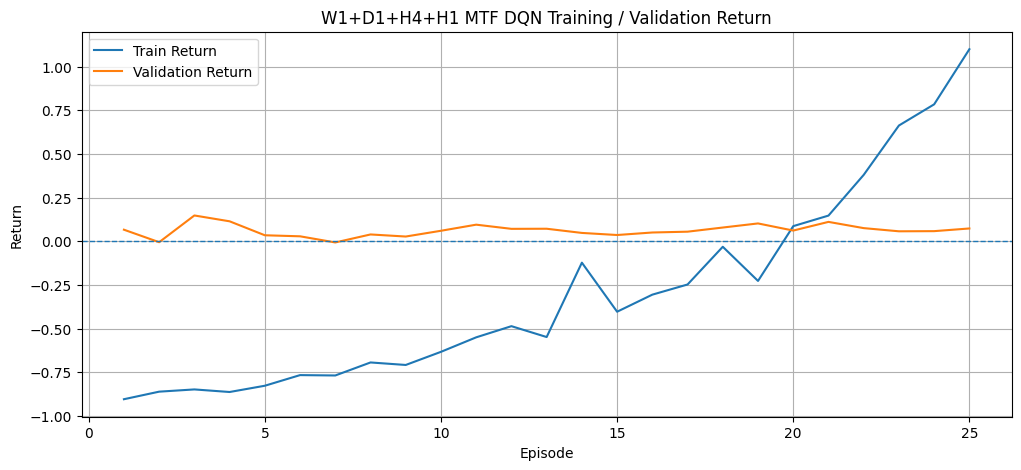

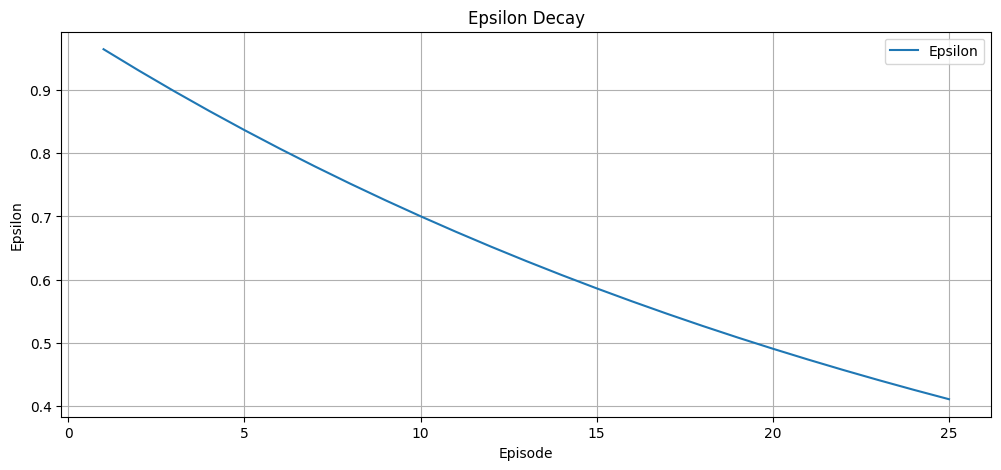

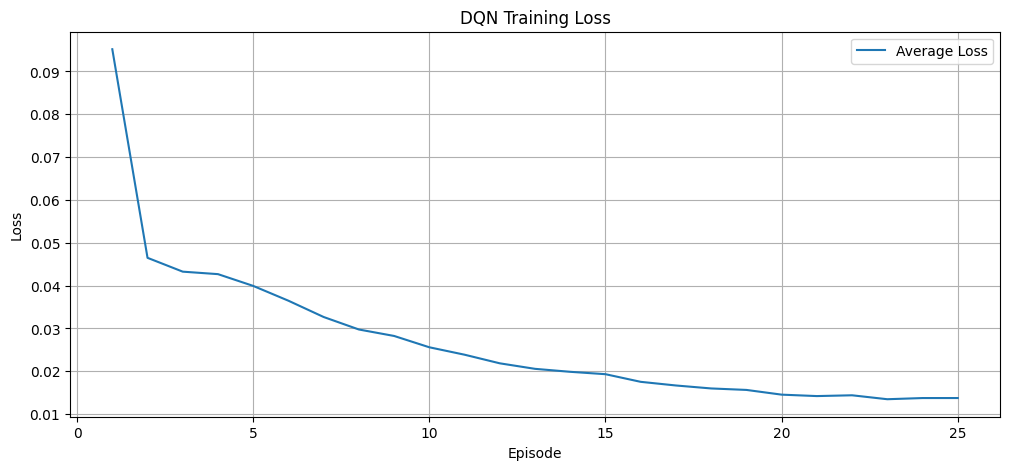

In [13]:
plt.figure(figsize=(12, 5))
plt.plot(logs_df["episode"], logs_df["train_return"], label="Train Return")
plt.plot(logs_df["episode"], logs_df["val_return"], label="Validation Return")
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("W1+D1+H4+H1 MTF DQN Training / Validation Return")
plt.xlabel("Episode")
plt.ylabel("Return")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(logs_df["episode"], logs_df["epsilon"], label="Epsilon")
plt.title("Epsilon Decay")
plt.xlabel("Episode")
plt.ylabel("Epsilon")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(logs_df["episode"], logs_df["avg_loss"], label="Average Loss")
plt.title("DQN Training Loss")
plt.xlabel("Episode")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# ============================================================
# Cell 14：回測與績效指標
# ============================================================

In [14]:
def calculate_metrics(equity_df: pd.DataFrame, trades_df: pd.DataFrame, initial_cash: float) -> Dict:
    if equity_df.empty:
        return {}

    final_value = equity_df["portfolio_value"].iloc[-1]
    total_return = final_value / initial_cash - 1.0

    returns = equity_df["portfolio_value"].pct_change().dropna()
    max_drawdown = equity_df["drawdown"].max()

    sharpe = np.nan
    if len(returns) > 1 and returns.std() > 0:
        # 1H 粗略年化：每年約 252 交易日，每日約 6.5 小時
        sharpe = (returns.mean() / returns.std()) * np.sqrt(252 * 6.5)

    win_periods = (returns > 0).sum()
    total_periods = len(returns)
    period_win_rate = win_periods / total_periods if total_periods > 0 else np.nan

    gross_profit = returns[returns > 0].sum()
    gross_loss = abs(returns[returns < 0].sum())
    profit_factor = gross_profit / gross_loss if gross_loss > 0 else np.nan

    trade_win_rate = np.nan
    completed_trade_returns = []

    if not trades_df.empty and "type" in trades_df.columns:
        buy_price = None
        for _, row in trades_df.iterrows():
            if row["type"] == "BUY" and buy_price is None:
                buy_price = row["price"]
            elif row["type"] == "SELL" and buy_price is not None:
                sell_price = row["price"]
                completed_trade_returns.append(sell_price / buy_price - 1.0)
                buy_price = None

        if completed_trade_returns:
            trade_win_rate = np.mean([r > 0 for r in completed_trade_returns])

    return {
        "final_value": final_value,
        "total_return": total_return,
        "max_drawdown": max_drawdown,
        "sharpe_ratio": sharpe,
        "period_win_rate": period_win_rate,
        "trade_win_rate": trade_win_rate,
        "profit_factor": profit_factor,
        "num_trades": 0 if trades_df.empty else len(trades_df),
    }


def backtest(env: MTFTradingEnv, agent: DQNAgent) -> Dict:
    state = env.reset()
    actions = []
    q_records = []

    while True:
        q_values = agent.get_q_values(state)
        action = int(np.argmax(q_values))
        next_state, reward, done, info = env.step(action)

        actions.append({
            "step": env.step_idx,
            "datetime": env.df.loc[env.step_idx, "datetime"],
            "action": action,
            "action_name": ACTION_NAMES[action],
            "target_ratio": ACTION_POSITION_RATIOS[action],
            "portfolio_value": info["portfolio_value"],
            "period_return": info["period_return"],
            "drawdown": info["drawdown"],
            "mtf_confluence_score": info["mtf_confluence_score"],
        })

        q_records.append(q_values)
        state = next_state
        if done:
            break

    equity_df = pd.DataFrame(env.equity_curve)
    actions_df = pd.DataFrame(actions)
    trades_df = pd.DataFrame(env.trades)
    q_df = pd.DataFrame(q_records, columns=[f"Q_{ACTION_NAMES[i]}" for i in range(len(ACTION_NAMES))])

    metrics = calculate_metrics(equity_df, trades_df, env.initial_cash)

    return {
        "equity_df": equity_df,
        "actions_df": actions_df,
        "trades_df": trades_df,
        "q_df": q_df,
        "metrics": metrics,
    }


test_env = make_env(test_df, cfg)
bt = backtest(test_env, agent)
metrics = bt["metrics"]

print("========== Test Backtest Metrics ==========")
for k, v in metrics.items():
    if isinstance(v, float):
        if "rate" in k or "return" in k or "drawdown" in k:
            print(f"{k}: {v:.2%}")
        else:
            print(f"{k}: {v:.4f}")
    else:
        print(f"{k}: {v}")
print(f"epsilon: {agent.epsilon:.4f}")

========== Test Backtest Metrics ==========
final_value: 100408.7857
total_return: 0.41%
max_drawdown: 11.05%
sharpe_ratio: 0.0951
period_win_rate: 27.91%
trade_win_rate: 46.43%
profit_factor: 1.0085
num_trades: 283
epsilon: 0.4104


# ============================================================
# Cell 15：回測視覺化
# ============================================================

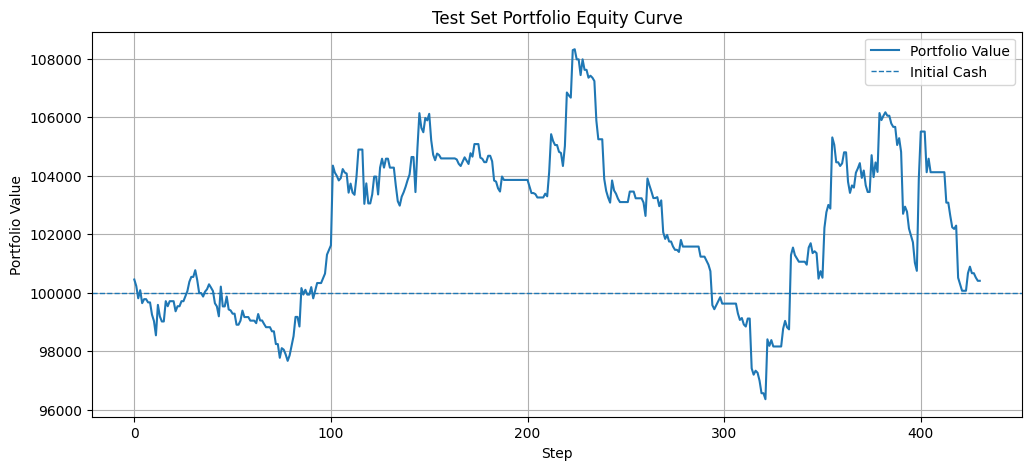

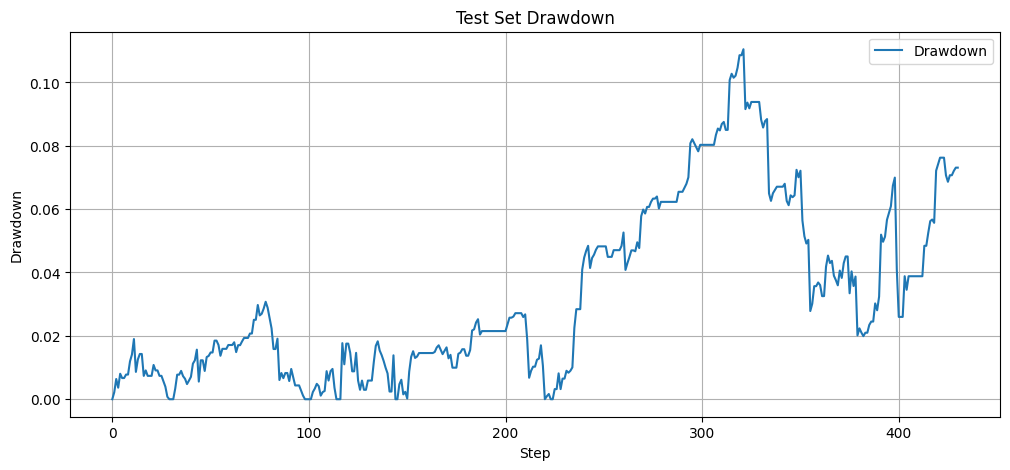

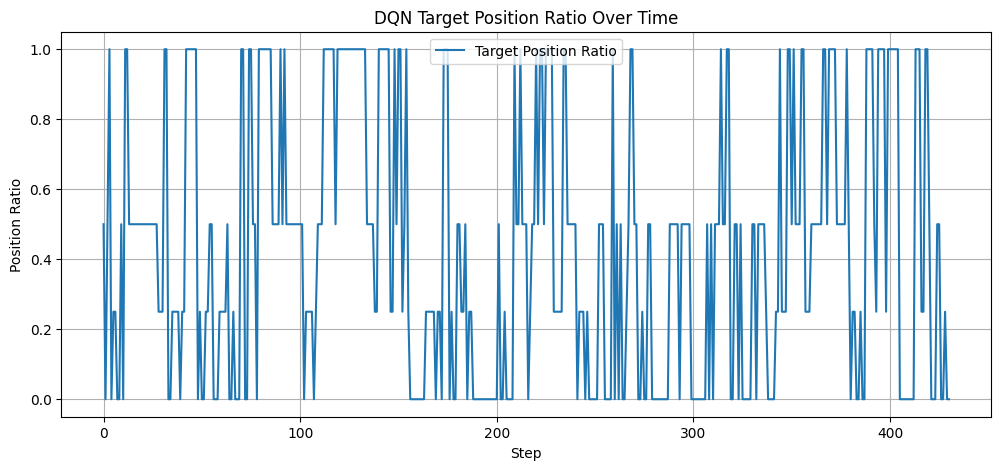

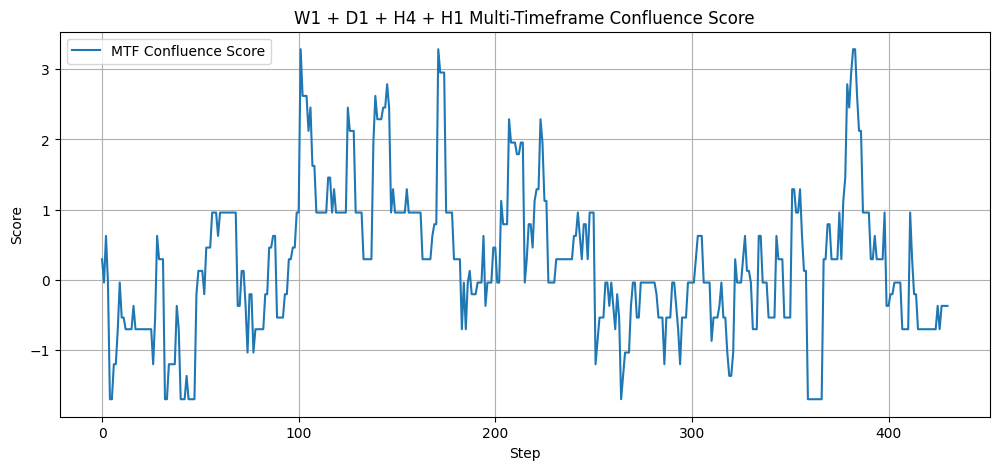

Recent trades:


,step,datetime,type,price,value,cost
273,416,2026-05-08 01:00:00,SELL,2300.0,76975.811456,340.617966
274,417,2026-05-08 03:00:00,SELL,2295.0,43.319811,0.191690
275,418,2026-05-08 04:00:00,BUY,2290.0,76678.321611,109.266608
276,420,2026-05-11 01:00:00,SELL,2255.0,50256.404239,222.384589
277,421,2026-05-11 03:00:00,SELL,2255.0,50256.404239,222.384589
278,424,2026-05-12 01:00:00,BUY,2225.0,50034.019651,71.298478
279,425,2026-05-12 03:00:00,SELL,2255.0,301.178095,1.332713
280,426,2026-05-12 04:00:00,SELL,2265.0,50558.413700,223.720981
281,428,2026-05-13 01:00:00,BUY,2220.0,25167.139438,35.863174
282,429,2026-05-13 03:00:00,SELL,2210.0,25018.072317,110.704970


In [15]:
equity_df = bt["equity_df"]
actions_df = bt["actions_df"]
trades_df = bt["trades_df"]
q_df = bt["q_df"]

plt.figure(figsize=(12, 5))
plt.plot(equity_df["portfolio_value"], label="Portfolio Value")
plt.axhline(cfg.initial_cash, linestyle="--", linewidth=1, label="Initial Cash")
plt.title("Test Set Portfolio Equity Curve")
plt.xlabel("Step")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(equity_df["drawdown"], label="Drawdown")
plt.title("Test Set Drawdown")
plt.xlabel("Step")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(actions_df["target_ratio"], label="Target Position Ratio")
plt.title("DQN Target Position Ratio Over Time")
plt.xlabel("Step")
plt.ylabel("Position Ratio")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(equity_df["mtf_confluence_score"], label="MTF Confluence Score")
plt.title("W1 + D1 + H4 + H1 Multi-Timeframe Confluence Score")
plt.xlabel("Step")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()

print("Recent trades:")
display(trades_df.tail(10))

# ============================================================
# Cell 16：最新資料推論與策略建議
# ============================================================

In [16]:
def build_mtf_dataset_from_raw(
    df_h1_raw: pd.DataFrame,
    df_d1_raw: pd.DataFrame,
    cfg: Config,
) -> pd.DataFrame:
    """由 H1 / D1 raw data 重建 W1 + D1 + H4 + H1 MTF dataset。"""
    df_h1_raw = ensure_datetime_index(df_h1_raw)
    df_d1_raw = ensure_datetime_index(df_d1_raw)
    df_h4_raw = resample_ohlcv(df_h1_raw, "4h")
    df_w1_raw = resample_ohlcv(df_d1_raw, "1W")

    df_h1_feat = prepare_timeframe_features(df_h1_raw, "h1", cfg)
    df_h4_feat = prepare_timeframe_features(df_h4_raw, "h4", cfg)
    df_d1_feat = prepare_timeframe_features(df_d1_raw, "d1", cfg)
    df_w1_feat = prepare_timeframe_features(df_w1_raw, "w1", cfg)

    h4_cols = select_prefixed_feature_columns(df_h4_feat, "h4")
    d1_cols = select_prefixed_feature_columns(df_d1_feat, "d1")
    w1_cols = select_prefixed_feature_columns(df_w1_feat, "w1")

    out = merge_asof_higher_tf(df_h1_feat, df_h4_feat, h4_cols)
    out = merge_asof_higher_tf(out, df_d1_feat, d1_cols)
    out = merge_asof_higher_tf(out, df_w1_feat, w1_cols)
    out = out.replace([np.inf, -np.inf], np.nan).dropna()
    out = add_mtf_confluence_features(out)

    out = add_risk_reward_features_by_timeframe(
        out,
        prefixes=("w1", "d1", "h4", "h1"),
        atr_multiplier=cfg.rr_atr_multiplier,
        target_rr=cfg.rr_target,
        swing_buffer_pct=cfg.rr_swing_buffer_pct,
        min_rr_threshold=cfg.min_rr_threshold,
    )

    out = out.replace([np.inf, -np.inf], np.nan).dropna()
    return out


def rebuild_latest_mtf_dataset(cfg: Config) -> pd.DataFrame:
    latest_h1 = download_ohlcv_with_fallback(
        ticker=cfg.ticker,
        start=cfg.start_date,
        end=cfg.end_date,
        interval=cfg.base_interval,
        fallback_periods=cfg.intraday_fallback_periods,
    )

    latest_daily_start = str((latest_h1.index.min() - pd.Timedelta(days=cfg.daily_extra_days)).date())
    latest_daily_end = str((latest_h1.index.max() + pd.Timedelta(days=2)).date())

    latest_d1 = download_ohlcv_with_fallback(
        ticker=cfg.ticker,
        start=latest_daily_start,
        end=latest_daily_end,
        interval="1d",
        fallback_periods=("10y", "5y", "2y", "1y"),
    )

    latest_mtf = build_mtf_dataset_from_raw(latest_h1, latest_d1, cfg)
    return latest_mtf


def build_latest_state(
    latest_mtf_raw: pd.DataFrame,
    feature_cols: List[str],
    feature_mean: pd.Series,
    feature_std: pd.Series,
    current_cash: float,
    current_shares: float,
    initial_cash: float,
):
    latest_scaled = apply_standardizer(latest_mtf_raw, feature_cols, feature_mean, feature_std)

    latest_row_scaled = latest_scaled.iloc[-1]
    latest_row_raw = latest_mtf_raw.iloc[-1]

    features = latest_row_scaled[feature_cols].values.astype(np.float32)
    price = float(latest_row_raw["close"])
    portfolio_value = current_cash + current_shares * price

    cash_ratio = current_cash / max(portfolio_value, 1e-8)
    position_ratio = (current_shares * price) / max(portfolio_value, 1e-8)
    unrealized_pnl_ratio = portfolio_value / max(initial_cash, 1e-8) - 1.0

    portfolio_features = np.array([
        cash_ratio,
        position_ratio,
        unrealized_pnl_ratio,
    ], dtype=np.float32)

    state = np.concatenate([features, portfolio_features])
    return state, latest_row_raw, price, portfolio_value


def calculate_risk_reward_plan(
    latest_row: pd.Series,
    current_price: float,
    target_position_ratio: float,
    current_position_ratio: float,
    atr_multiplier: float = 1.5,
    target_rr: float = 2.0,
    swing_buffer_pct: float = 0.002,
) -> Dict:
    """
    根據最新多時區 SMC 狀態，估算進場價、停損價、停利價與 Risk Reward Ratio。

    目前版本適用於現貨多方策略：
    - 若模型建議增加部位，提供 long entry plan
    - 若模型建議空手或降低部位，則不提供新的進場價
    """

    entry_price = float(current_price)

    # 判斷是否為新增 / 增加多方部位
    is_long_entry = target_position_ratio > current_position_ratio

    if not is_long_entry:
        return {
            "risk_reward_valid": False,
            "entry_price": None,
            "stop_loss_price": None,
            "take_profit_price": None,
            "risk_per_share": None,
            "reward_per_share": None,
            "risk_reward_ratio": None,
            "risk_reward_note": "No new long entry suggested. Model is holding, reducing, or staying in cash.",
        }

    # 取得 ATR，優先使用 H1 ATR
    h1_atr = latest_row.get("h1_atr", np.nan)
    h4_atr = latest_row.get("h4_atr", np.nan)

    if pd.isna(h1_atr) or h1_atr <= 0:
        atr_value = h4_atr
    else:
        atr_value = h1_atr

    if pd.isna(atr_value) or atr_value <= 0:
        return {
            "risk_reward_valid": False,
            "entry_price": entry_price,
            "stop_loss_price": None,
            "take_profit_price": None,
            "risk_per_share": None,
            "reward_per_share": None,
            "risk_reward_ratio": None,
            "risk_reward_note": "ATR is unavailable, so stop-loss and take-profit cannot be estimated.",
        }

    # ATR 停損
    atr_stop = entry_price - atr_multiplier * float(atr_value)

    # SMC 結構停損：使用 H1 / H4 最近 swing low
    h1_swing_low = latest_row.get("h1_last_swing_low", np.nan)
    h4_swing_low = latest_row.get("h4_last_swing_low", np.nan)

    stop_candidates = []

    # ATR stop 候選
    if atr_stop < entry_price:
        stop_candidates.append(atr_stop)

    # H1 swing low 候選
    if not pd.isna(h1_swing_low) and h1_swing_low < entry_price:
        stop_candidates.append(float(h1_swing_low) * (1 - swing_buffer_pct))

    # H4 swing low 候選
    if not pd.isna(h4_swing_low) and h4_swing_low < entry_price:
        stop_candidates.append(float(h4_swing_low) * (1 - swing_buffer_pct))

    if not stop_candidates:
        return {
            "risk_reward_valid": False,
            "entry_price": entry_price,
            "stop_loss_price": None,
            "take_profit_price": None,
            "risk_per_share": None,
            "reward_per_share": None,
            "risk_reward_ratio": None,
            "risk_reward_note": "No valid stop-loss candidate below entry price.",
        }

    # 選擇最接近進場價、但仍在進場價下方的停損
    # 這樣風險不會被拉得過大
    stop_loss_price = max(stop_candidates)

    risk_per_share = entry_price - stop_loss_price

    if risk_per_share <= 0:
        return {
            "risk_reward_valid": False,
            "entry_price": entry_price,
            "stop_loss_price": stop_loss_price,
            "take_profit_price": None,
            "risk_per_share": None,
            "reward_per_share": None,
            "risk_reward_ratio": None,
            "risk_reward_note": "Invalid stop-loss price. Stop-loss must be below entry price.",
        }

    # 基礎停利：依目標 RR 計算
    rr_take_profit = entry_price + risk_per_share * target_rr

    # SMC 結構停利參考：最近 swing high
    h1_swing_high = latest_row.get("h1_last_swing_high", np.nan)
    h4_swing_high = latest_row.get("h4_last_swing_high", np.nan)
    d1_swing_high = latest_row.get("d1_last_swing_high", np.nan)

    resistance_candidates = []

    for level in [h1_swing_high, h4_swing_high, d1_swing_high]:
        if not pd.isna(level) and float(level) > entry_price:
            resistance_candidates.append(float(level))

    # 若上方有結構壓力，提供「較近的結構停利」與「RR 停利」中較合理者
    # MVP 版本：若最近壓力的 RR >= 1.2，優先採用最近壓力；否則使用 target_rr 停利。
    take_profit_price = rr_take_profit
    take_profit_basis = f"Target RR {target_rr:.1f}x"

    if resistance_candidates:
        nearest_resistance = min(resistance_candidates)
        structure_rr = (nearest_resistance - entry_price) / risk_per_share

        if structure_rr >= 1.2:
            take_profit_price = nearest_resistance
            take_profit_basis = "Nearest SMC swing high / resistance"
        else:
            take_profit_price = rr_take_profit
            take_profit_basis = f"Target RR {target_rr:.1f}x; nearest resistance RR too low"

    reward_per_share = take_profit_price - entry_price
    risk_reward_ratio = reward_per_share / risk_per_share

    return {
        "risk_reward_valid": True,
        "entry_price": entry_price,
        "stop_loss_price": stop_loss_price,
        "take_profit_price": take_profit_price,
        "risk_per_share": risk_per_share,
        "reward_per_share": reward_per_share,
        "risk_reward_ratio": risk_reward_ratio,
        "take_profit_basis": take_profit_basis,
        "atr_used": float(atr_value),
        "atr_multiplier": atr_multiplier,
        "target_rr": target_rr,
        "risk_reward_note": "Long entry risk plan generated from ATR and SMC swing structure.",
    }

def recommend_strategy(
    agent: DQNAgent,
    latest_mtf_raw: pd.DataFrame,
    cfg: Config,
    feature_cols: List[str],
    feature_mean: pd.Series,
    feature_std: pd.Series,
    current_cash: float,
    current_shares: float,
):
    state, latest_row, price, portfolio_value = build_latest_state(
        latest_mtf_raw=latest_mtf_raw,
        feature_cols=feature_cols,
        feature_mean=feature_mean,
        feature_std=feature_std,
        current_cash=current_cash,
        current_shares=current_shares,
        initial_cash=cfg.initial_cash,
    )

    q_values = agent.get_q_values(state)
    best_action = int(np.argmax(q_values))
    target_ratio = ACTION_POSITION_RATIOS[best_action]

    target_position_value = portfolio_value * target_ratio
    current_position_value = current_shares * price
    trade_value = target_position_value - current_position_value

    current_position_ratio = current_position_value / max(portfolio_value, 1e-8)

    risk_reward_plan = calculate_risk_reward_plan(
        latest_row=latest_row,
        current_price=price,
        target_position_ratio=target_ratio,
        current_position_ratio=current_position_ratio,
        atr_multiplier=1.5,
        target_rr=2.0,
        swing_buffer_pct=0.002,
    )

    if trade_value > 0:
        trade_direction = "BUY"
    elif trade_value < 0:
        trade_direction = "SELL"
    else:
        trade_direction = "HOLD"

    result = {
        "ticker": cfg.ticker,
        "latest_datetime": latest_row.name,
        "latest_close": price,
        "current_cash": current_cash,
        "current_shares": current_shares,
        "current_portfolio_value": portfolio_value,
        "best_action_id": best_action,
        "best_action_name": ACTION_NAMES[best_action],
        "target_position_ratio": target_ratio,
        "target_position_value": target_position_value,
        "trade_direction": trade_direction,
        "suggested_trade_value": abs(trade_value),
        "epsilon": agent.epsilon,
        "q_values": {ACTION_NAMES[i]: float(q_values[i]) for i in range(len(q_values))},
        "risk_reward_plan": risk_reward_plan,
        # 新增 W1 / D1 / H4 / H1 多週期 Risk Reward Ratio
        "multi_timeframe_risk_reward": {
            "W1": {
                "entry_price": float(latest_row["w1_rr_entry_price"]),
                "stop_loss_price": float(latest_row["w1_rr_stop_loss_price"]),
                "take_profit_price": float(latest_row["w1_rr_take_profit_price"]),
                "risk_pct": float(latest_row["w1_rr_risk_pct"]),
                "reward_pct": float(latest_row["w1_rr_reward_pct"]),
                "risk_reward_ratio": float(latest_row["w1_rr_ratio"]),
                "rr_valid": int(latest_row["w1_rr_valid"]),
                "rr_quality_score": float(latest_row["w1_rr_quality_score"]),
                "take_profit_basis": str(latest_row["w1_rr_take_profit_basis"]),
            },
            "D1": {
                "entry_price": float(latest_row["d1_rr_entry_price"]),
                "stop_loss_price": float(latest_row["d1_rr_stop_loss_price"]),
                "take_profit_price": float(latest_row["d1_rr_take_profit_price"]),
                "risk_pct": float(latest_row["d1_rr_risk_pct"]),
                "reward_pct": float(latest_row["d1_rr_reward_pct"]),
                "risk_reward_ratio": float(latest_row["d1_rr_ratio"]),
                "rr_valid": int(latest_row["d1_rr_valid"]),
                "rr_quality_score": float(latest_row["d1_rr_quality_score"]),
                "take_profit_basis": str(latest_row["d1_rr_take_profit_basis"]),
            },
            "H4": {
                "entry_price": float(latest_row["h4_rr_entry_price"]),
                "stop_loss_price": float(latest_row["h4_rr_stop_loss_price"]),
                "take_profit_price": float(latest_row["h4_rr_take_profit_price"]),
                "risk_pct": float(latest_row["h4_rr_risk_pct"]),
                "reward_pct": float(latest_row["h4_rr_reward_pct"]),
                "risk_reward_ratio": float(latest_row["h4_rr_ratio"]),
                "rr_valid": int(latest_row["h4_rr_valid"]),
                "rr_quality_score": float(latest_row["h4_rr_quality_score"]),
                "take_profit_basis": str(latest_row["h4_rr_take_profit_basis"]),
            },
            "H1": {
                "entry_price": float(latest_row["h1_rr_entry_price"]),
                "stop_loss_price": float(latest_row["h1_rr_stop_loss_price"]),
                "take_profit_price": float(latest_row["h1_rr_take_profit_price"]),
                "risk_pct": float(latest_row["h1_rr_risk_pct"]),
                "reward_pct": float(latest_row["h1_rr_reward_pct"]),
                "risk_reward_ratio": float(latest_row["h1_rr_ratio"]),
                "rr_valid": int(latest_row["h1_rr_valid"]),
                "rr_quality_score": float(latest_row["h1_rr_quality_score"]),
                "take_profit_basis": str(latest_row["h1_rr_take_profit_basis"]),
            },
        },
        "mtf_snapshot": {
            "w1_smc_bias": float(latest_row["w1_smc_bias"]),
            "d1_smc_bias": float(latest_row["d1_smc_bias"]),
            "h4_smc_bias": float(latest_row["h4_smc_bias"]),
            "h1_smc_bias": float(latest_row["h1_smc_bias"]),
            "mtf_bullish_score": float(latest_row["mtf_bullish_score"]),
            "mtf_bearish_score": float(latest_row["mtf_bearish_score"]),
            "mtf_confluence_score": float(latest_row["mtf_confluence_score"]),
            "mtf_conflict": int(latest_row["mtf_conflict"]),
            "mtf_all_bullish": int(latest_row["mtf_all_bullish"]),
            "mtf_all_bearish": int(latest_row["mtf_all_bearish"]),
            "higher_tf_bullish": int(latest_row["higher_tf_bullish"]),
            "higher_tf_bearish": int(latest_row["higher_tf_bearish"]),
            "w1_structure_direction": int(latest_row["w1_structure_direction"]),
            "d1_structure_direction": int(latest_row["d1_structure_direction"]),
            "h4_structure_direction": int(latest_row["h4_structure_direction"]),
            "h1_structure_direction": int(latest_row["h1_structure_direction"]),
            "d1_choch_bullish": int(latest_row["d1_choch_bullish"]),
            "d1_choch_bearish": int(latest_row["d1_choch_bearish"]),
            "h4_choch_bullish": int(latest_row["h4_choch_bullish"]),
            "h4_choch_bearish": int(latest_row["h4_choch_bearish"]),
            "h1_choch_bullish": int(latest_row["h1_choch_bullish"]),
            "h1_choch_bearish": int(latest_row["h1_choch_bearish"]),
            "h4_liquidity_sweep_high": int(latest_row["h4_liquidity_sweep_high"]),
            "h4_liquidity_sweep_low": int(latest_row["h4_liquidity_sweep_low"]),
            "h1_liquidity_sweep_high": int(latest_row["h1_liquidity_sweep_high"]),
            "h1_liquidity_sweep_low": int(latest_row["h1_liquidity_sweep_low"]),
        }
    }
    return result


# 輸入目前資金與持股
CURRENT_CASH = 100000.0
CURRENT_SHARES = 0.0

# 使用已下載資料建立最新策略建議；若想重新抓最新資料，可改用 rebuild_latest_mtf_dataset(cfg)
latest_mtf_raw = mtf_df.copy()

recommendation = recommend_strategy(
    agent=agent,
    latest_mtf_raw=latest_mtf_raw,
    cfg=cfg,
    feature_cols=FEATURE_COLUMNS,
    feature_mean=feature_mean,
    feature_std=feature_std,
    current_cash=CURRENT_CASH,
    current_shares=CURRENT_SHARES,
)

print("========== Latest W1+D1+H4+H1 MTF Strategy Recommendation ==========")
print(f"Ticker: {recommendation['ticker']}")
print(f"Latest Datetime: {recommendation['latest_datetime']}")
print(f"Latest Close: {recommendation['latest_close']:.2f}")
print(f"Current Cash: {recommendation['current_cash']:.2f}")
print(f"Current Shares: {recommendation['current_shares']:.4f}")
print(f"Current Portfolio Value: {recommendation['current_portfolio_value']:.2f}")
print("--------------------------------------------------------------------")
print(f"Best Action: {recommendation['best_action_name']}")
print(f"Trade Direction: {recommendation['trade_direction']}")
print(f"Target Position Ratio: {recommendation['target_position_ratio']:.0%}")
print(f"Target Position Value: {recommendation['target_position_value']:.2f}")
print(f"Suggested Trade Value: {recommendation['suggested_trade_value']:.2f}")
print(f"Epsilon: {recommendation['epsilon']:.4f}")
print("--------------------------------------------------------------------")
print("Q Values:")
for action_name, q in recommendation["q_values"].items():
    print(f"- {action_name}: {q:.6f}")
print("--------------------------------------------------------------------")
print("Risk Reward Plan:")

rr_plan = recommendation["risk_reward_plan"]

print(f"Valid Plan: {rr_plan['risk_reward_valid']}")
print(f"Note: {rr_plan['risk_reward_note']}")

if rr_plan["risk_reward_valid"]:
    print(f"Entry Price: {rr_plan['entry_price']:.2f}")
    print(f"Stop Loss Price: {rr_plan['stop_loss_price']:.2f}")
    print(f"Take Profit Price: {rr_plan['take_profit_price']:.2f}")
    print(f"Risk per Share: {rr_plan['risk_per_share']:.2f}")
    print(f"Reward per Share: {rr_plan['reward_per_share']:.2f}")
    print(f"Risk Reward Ratio: {rr_plan['risk_reward_ratio']:.2f}")
    print(f"Take Profit Basis: {rr_plan['take_profit_basis']}")
    print(f"ATR Used: {rr_plan['atr_used']:.2f}")
    print(f"ATR Multiplier: {rr_plan['atr_multiplier']:.2f}")
    print(f"Target RR: {rr_plan['target_rr']:.2f}")

print("--------------------------------------------------------------------")
print("Multi-Timeframe Risk Reward Ratios:")

mtf_rr = recommendation["multi_timeframe_risk_reward"]

for tf_name, tf_rr in mtf_rr.items():
    print(
        f"[{tf_name}] "
        f"Entry: {tf_rr['entry_price']:.2f} | "
        f"SL: {tf_rr['stop_loss_price']:.2f} | "
        f"TP: {tf_rr['take_profit_price']:.2f} | "
        f"Risk: {tf_rr['risk_pct']:.2%} | "
        f"Reward: {tf_rr['reward_pct']:.2%} | "
        f"RR: {tf_rr['risk_reward_ratio']:.2f} | "
        f"Valid: {tf_rr['rr_valid']} | "
        f"Basis: {tf_rr['take_profit_basis']}"
    )

print("--------------------------------------------------------------------")
print("MTF Snapshot:")
for k, v in recommendation["mtf_snapshot"].items():
    print(f"- {k}: {v}")
print("--------------------------------------------------------------------")
print("Backtest Summary:")
print(f"Period Win Rate: {metrics.get('period_win_rate', np.nan):.2%}")
print(f"Trade Win Rate: {metrics.get('trade_win_rate', np.nan):.2%}")
print(f"Total Return: {metrics.get('total_return', np.nan):.2%}")
print(f"Max Drawdown: {metrics.get('max_drawdown', np.nan):.2%}")
print(f"Sharpe Ratio: {metrics.get('sharpe_ratio', np.nan):.4f}")
print(f"Profit Factor: {metrics.get('profit_factor', np.nan):.4f}")

========== Latest W1+D1+H4+H1 MTF Strategy Recommendation ==========
Ticker: 2330.TW
Latest Datetime: 2026-05-13 05:00:00
Latest Close: 2235.00
Current Cash: 100000.00
Current Shares: 0.0000
Current Portfolio Value: 100000.00
--------------------------------------------------------------------
Best Action: Adjust to 50% Position
Trade Direction: BUY
Target Position Ratio: 50%
Target Position Value: 50000.00
Suggested Trade Value: 50000.00
Epsilon: 0.4104
--------------------------------------------------------------------
Q Values:
- Stay in Cash / 0% Position: 0.527783
- Adjust to 25% Position: 0.448467
- Adjust to 50% Position: 0.563266
- Adjust to 100% Position: -0.436049
--------------------------------------------------------------------
Risk Reward Plan:
Valid Plan: True
Note: Long entry risk plan generated from ATR and SMC swing structure.
Entry Price: 2235.00
Stop Loss Price: 2201.18
Take Profit Price: 2280.00
Risk per Share: 33.82
Reward per Share: 45.00
Risk Reward Ratio: 1.3

# ============================================================
# Cell 17：輸出 CSV 報告
# ============================================================

In [ ]:
logs_df.to_csv("mtf_w1_d1_h4_h1_training_logs.csv", index=False)
bt["equity_df"].to_csv("mtf_w1_d1_h4_h1_test_equity_curve.csv", index=False)
bt["actions_df"].to_csv("mtf_w1_d1_h4_h1_test_actions.csv", index=False)
bt["trades_df"].to_csv("mtf_w1_d1_h4_h1_test_trades.csv", index=False)
bt["q_df"].to_csv("mtf_w1_d1_h4_h1_test_q_values.csv", index=False)

rr_plan = recommendation["risk_reward_plan"]

summary_df = pd.DataFrame([{
    "ticker": cfg.ticker,
    "epsilon": agent.epsilon,
    **metrics,
    "best_action": recommendation["best_action_name"],
    "trade_direction": recommendation["trade_direction"],
    "target_position_ratio": recommendation["target_position_ratio"],
    "suggested_trade_value": recommendation["suggested_trade_value"],

    # Risk Reward Plan
    "risk_reward_valid": rr_plan["risk_reward_valid"],
    "entry_price": rr_plan["entry_price"],
    "stop_loss_price": rr_plan["stop_loss_price"],
    "take_profit_price": rr_plan["take_profit_price"],
    "risk_per_share": rr_plan["risk_per_share"],
    "reward_per_share": rr_plan["reward_per_share"],
    "risk_reward_ratio": rr_plan["risk_reward_ratio"],
    "risk_reward_note": rr_plan["risk_reward_note"],

    # MTF Snapshot
    **recommendation["mtf_snapshot"],
}])
summary_df.to_csv("mtf_w1_d1_h4_h1_strategy_summary.csv", index=False)

print("CSV files exported:")
print("- mtf_w1_d1_h4_h1_training_logs.csv")
print("- mtf_w1_d1_h4_h1_test_equity_curve.csv")
print("- mtf_w1_d1_h4_h1_test_actions.csv")
print("- mtf_w1_d1_h4_h1_test_trades.csv")
print("- mtf_w1_d1_h4_h1_test_q_values.csv")
print("- mtf_w1_d1_h4_h1_strategy_summary.csv")

CSV files exported:
- mtf_w1_d1_h4_h1_training_logs.csv
- mtf_w1_d1_h4_h1_test_equity_curve.csv
- mtf_w1_d1_h4_h1_test_actions.csv
- mtf_w1_d1_h4_h1_test_trades.csv
- mtf_w1_d1_h4_h1_test_q_values.csv
- mtf_w1_d1_h4_h1_strategy_summary.csv


# ============================================================
# Cell 18：儲存模型
# ============================================================

In [ ]:
torch.save({
    "model_state_dict": agent.policy_net.state_dict(),
    "feature_columns": FEATURE_COLUMNS,
    "feature_mean": feature_mean.to_dict(),
    "feature_std": feature_std.to_dict(),
    "config": cfg.__dict__,
    "epsilon": agent.epsilon,
    "action_position_ratios": ACTION_POSITION_RATIOS,
    "action_names": ACTION_NAMES,
}, "mtf_w1_d1_h4_h1_dqn_smc_trading_model.pth")

print("Model saved: mtf_w1_d1_h4_h1_dqn_smc_trading_model.pth")

Model saved: mtf_w1_d1_h4_h1_dqn_smc_trading_model.pth


# ============================================================
# Cell 19：載入模型範例
# ============================================================

In [ ]:
checkpoint = torch.load("mtf_w1_d1_h4_h1_dqn_smc_trading_model.pth", map_location=DEVICE)
FEATURE_COLUMNS_LOADED = checkpoint["feature_columns"]
feature_mean_loaded = pd.Series(checkpoint["feature_mean"])
feature_std_loaded = pd.Series(checkpoint["feature_std"])
cfg_loaded = Config(**checkpoint["config"])
state_dim_loaded = len(FEATURE_COLUMNS_LOADED) + 3
action_dim_loaded = len(checkpoint["action_position_ratios"])
loaded_agent = DQNAgent(state_dim_loaded, action_dim_loaded, cfg_loaded)
loaded_agent.policy_net.load_state_dict(checkpoint["model_state_dict"])
loaded_agent.target_net.load_state_dict(checkpoint["model_state_dict"])
loaded_agent.epsilon = checkpoint["epsilon"]
loaded_agent.policy_net.eval()
loaded_agent.target_net.eval()
print("Loaded model successfully. Epsilon:", loaded_agent.epsilon)


Loaded model successfully. Epsilon: 0.11793393801864926


# ============================================================
# Cell 20：載入模型後，使用最新資料產生策略建議範例
# ============================================================

In [ ]:
# 1. 可選：如果想改用其他股票，在這裡改
cfg_infer = Config(**checkpoint["config"])
cfg_infer.ticker = "AAPL"   # 例如改成 AAPL；若要原本股票就改回 cfg_loaded.ticker
cfg_infer.start_date = "2025-01-01"
cfg_infer.end_date = "2026-04-29"

# 2. 重新下載最新資料並建立多時區資料
latest_mtf_raw_loaded = rebuild_latest_mtf_dataset(cfg_infer)

# 3. 輸入目前資金與持股
CURRENT_CASH = 100000.0
CURRENT_SHARES = 0.0

# 4. 產生策略建議
recommendation_loaded = recommend_strategy(
    agent=loaded_agent,
    latest_mtf_raw=latest_mtf_raw_loaded,
    cfg=cfg_infer,
    feature_cols=FEATURE_COLUMNS_LOADED,
    feature_mean=feature_mean_loaded,
    feature_std=feature_std_loaded,
    current_cash=CURRENT_CASH,
    current_shares=CURRENT_SHARES,
)

# 5. 輸出結果
print("========== Loaded Model Latest Strategy Recommendation ==========")
print(f"Ticker: {recommendation_loaded['ticker']}")
print(f"Latest Datetime: {recommendation_loaded['latest_datetime']}")
print(f"Latest Close: {recommendation_loaded['latest_close']:.2f}")
print(f"Best Action: {recommendation_loaded['best_action_name']}")
print(f"Trade Direction: {recommendation_loaded['trade_direction']}")
print(f"Target Position Ratio: {recommendation_loaded['target_position_ratio']:.0%}")
print(f"Suggested Trade Value: {recommendation_loaded['suggested_trade_value']:.2f}")

print("------------------------------------------------------------")
print("Q Values:")
for action_name, q in recommendation_loaded["q_values"].items():
    print(f"- {action_name}: {q:.6f}")

print("------------------------------------------------------------")
print("Risk Reward:")
if "risk_reward_features" in recommendation_loaded:
    rr = recommendation_loaded["risk_reward_features"]
    print(f"Entry Price: {rr['entry_price']:.2f}")
    print(f"Stop Loss Price: {rr['stop_loss_price']:.2f}")
    print(f"Take Profit Price: {rr['take_profit_price']:.2f}")
    print(f"Risk %: {rr['risk_pct']:.2%}")
    print(f"Reward %: {rr['reward_pct']:.2%}")
    print(f"Risk Reward Ratio: {rr['risk_reward_ratio']:.2f}")
    print(f"RR Valid: {rr['rr_valid']}")
    print(f"RR Quality Score: {rr['rr_quality_score']:.4f}")
else:
    print("Risk Reward features are not available in this recommendation result.")

print("------------------------------------------------------------")
print("MTF Snapshot:")
for k, v in recommendation_loaded["mtf_snapshot"].items():
    print(f"- {k}: {v}")

ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['2330.TW']: YFPricesMissingError('possibly delisted; no price data found  (1h 2024-04-29 -> 2026-04-29) (Yahoo error = "1h data not available for startTime=1714320000 and endTime=1777392000. The requested range must be within the last 730 days.")')


Trying fallback: interval=1h, period=730d ...
Downloaded by period fallback: rows=3640, 2023-04-27 01:00:00 -> 2026-04-30 05:00:00
Downloaded by start/end: rows=1262, 2021-02-17 00:00:00 -> 2026-04-30 00:00:00
========== Latest Strategy Recommendation ==========
Ticker: 2330.TW
Latest Datetime: 2026-04-30 05:00:00
Latest Close: 2170.00
Current Cash: 100000.00
Current Shares: 0.0000
Current Portfolio Value: 100000.00
----------------------------------------------------
Best Action: Stay in Cash / 0% Position
Trade Direction: HOLD
Target Position Ratio: 0%
Target Position Value: 0.00
Suggested Trade Value: 0.00
Epsilon: 0.1179
----------------------------------------------------
Q Values:
- Stay in Cash / 0% Position: 3.499424
- Adjust to 25% Position: 3.324268
- Adjust to 50% Position: 3.076308
- Adjust to 100% Position: 2.754074
----------------------------------------------------
MTF Snapshot:
- w1_smc_bias: 1.0
- d1_smc_bias: 0.0
- h4_smc_bias: -1.0
- h1_smc_bias: 1.0
- mtf_bullish_s